# DIF-PI — Decision Intelligence Framework for Purchase Intentions

This notebook is the end-to-end executive demo of the DIF-PI pipeline on a unified retail panel.  
It produces a single actionable pricing recommendation (delta, execution window and confidence label) and exports executive artifacts.

## Quickstart

1) Create the processed datasets
- `datasets/processed/difpi_transactions.csv`
- `datasets/processed/difpi_pricing_demand_panel.csv`

2) Train the global forecasting model once
- Model directory: `artifacts/models/scenario_gen_transformer_global/`
- DIF-PI will load this model and will not retrain it.

3) Run this notebook
- Selects a `CASE_SKU` from the TEST split.
- Fits TBWISA elasticity on the train segment of the selected SKU.
- Generates what-if scenarios, forecasts demand with the global transformer, screens via X-TBWISA, and prints the executive decision card.

## Pipeline

1. *Purchase intention (NPD)*: timing signal (when customers are likely to purchase next).  
3. *What-If pricing (TBWISA/X-TBWISA)*: simulate price deltas → forecast demand → compute revenue → detect optimal window.  
4. *Explainability screening (X-TBWISA)*: surrogate + SHAP drift + economic checks → *Accept / Accept_Caution / Flag*.  
5. *Executive policy**: applies guardrails → *EXECUTE* or *PILOT*.

## Outputs

- `decision_table_case_sku_*.csv`
- `decision_table_screened_case_sku_*.csv`
- `executive_summary_case_sku_*.json`
- `metrics_case_sku_*.csv`
- `windows_case_sku_*.csv`
- `shap_global_importance_case_sku_*.csv`


## 0) Configuration

This section defines the paths, thresholds, and protocol settings.

**Key things to check**
- `TX_PATH` and `PANEL_PATH` point to your EDA exports.
- `GLOBAL_FORECASTER_DIR` points to the pretrained global transformer directory.
- `SKU_HOLDOUT_ENABLED=True` enforces the TRAIN_SKUS / TEST_SKUS protocol.

**Most useful parameters**
- Eligibility strictness: `ELIGIBILITY_MODE` + `MIN_*` thresholds  
- Case selection: `CASE_SKU_OVERRIDE`  
- Scenario grid: `DELTAS_PCT`  
- Forecast horizon: `HORIZON`  
- Global model path: `GLOBAL_FORECASTER_DIR`


In [1]:
import numpy as np
import pandas as pd
import sys

import xgboost as xgbregressor
import shap
import json

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

from src.tbwisa import TBWISAGenerator
from src.loglinear_scenarios import LogLinearScenarioGeneration
from src.xgboost_scenarios import XGBoostScenarioGeneration
from src.npd import NPDModel

In [2]:
REPO_ROOT = Path('.').resolve()
sys.path.append(str(REPO_ROOT))

# Expected exports from your EDA notebook
TX_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_transactions.csv'
PANEL_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_pricing_demand_panel.csv'

OUT_DIR = REPO_ROOT / 'artifacts' / 'difpi_exec_demo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized columns (from EDA export)
CUST_COL='CustomerID'; DATE_COL='InvoiceDate'; SKU_COL='StockCode'
QTY_COL='Quantity'; UNITP_COL='UnitPrice'
TIME_COL='timestamp'; PRICE_COL='price'; DEMAND_COL='demand'

# Paper protocol thresholds (default = strict)
ELIGIBILITY_MODE = "adaptive"  # {"strict","relaxed","adaptive"}

# Strict filters
MIN_HISTORY_DAYS_STRICT = 365
MIN_NONZERO_DAYS_STRICT = 60

# Relaxed filters (for smaller / sparser panels)
MIN_HISTORY_DAYS_RELAXED = 120
MIN_NONZERO_DAYS_RELAXED = 30

# SKU-level evaluation protocol
# For evaluating generalization across SKUs, enable a SKU holdout split.
# The pipeline will:
# (1) select eligible SKUs,
# (2) split them into TRAIN_SKUS / TEST_SKUS,
# (3) identify suitable held-out SKUs for the three integrated case-study regimes,
# (4) let you run one selected case SKU through the existing executive workflow,
# (5) aggregate already-run cases into a cross-case comparative summary.
SKU_HOLDOUT_ENABLED = True
TEST_SKU_FRAC = 0.20
SPLIT_SEED = 42

# Case-study selection
CASE_REGIME_SELECTION = 'regular'   # {'regular', 'intermittent', 'price_sensitive'}
CASE_SKU_OVERRIDE = None         # set to a specific SKU id to force the executive case; otherwise set to None

EXPORT_SKU_SPLIT_LISTS = True

# For loglinear/XGBoost feature baselines (minimum positive rows after filtering)
MIN_POS_ROWS_LOGMODELS = 60

# Adaptive target: if strict yields too few eligible SKUs, thresholds are relaxed stepwise until we reach this fraction.
TARGET_ELIGIBLE_FRACTION = 0.8

# Decision grid + horizon
DELTAS_PCT = [-15, -12, -10, -7, -5, -2, 0, 2, 5, 7, 10, 12, 15]
HORIZON = 30

# Transformer training (demo defaults; increase epochs for final runs)
TRANSFORMER_SEQ_LEN = 30
TRANSFORMER_EPOCHS = 150
TRANSFORMER_BATCH = 32
TRANSFORMER_LR = 1e-3

# Global forecaster (trained once on TRAIN_SKUS; loaded in DIF-PI to avoid retraining)
GLOBAL_FORECASTER_DIR = REPO_ROOT / 'artifacts' / 'models' / 'scenario_gen_transformer_global'

SEED = 42
np.random.seed(SEED)

print('TX_PATH:', TX_PATH)
print('PANEL_PATH:', PANEL_PATH)
print('OUT_DIR:', OUT_DIR)

TX_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_transactions.csv
PANEL_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/difpi_exec_demo


## 1) Load dataset

In [3]:
if not TX_PATH.exists():
    raise FileNotFoundError(f'Missing {TX_PATH}. Run the EDA export notebook first.')
if not PANEL_PATH.exists():
    raise FileNotFoundError(f'Missing {PANEL_PATH}. Run the EDA export notebook first.')

tx = pd.read_csv(TX_PATH)
panel = pd.read_csv(PANEL_PATH)

# Normalize SKU dtype for consistent matching with train/test lists
if SKU_COL in tx.columns:
    tx[SKU_COL] = tx[SKU_COL].astype(str)
if SKU_COL in panel.columns:
    panel[SKU_COL] = panel[SKU_COL].astype(str)

tx[DATE_COL] = pd.to_datetime(tx[DATE_COL], errors='raise')
panel[TIME_COL] = pd.to_datetime(panel[TIME_COL], errors='raise')

# Basic schema checks
req_tx = {CUST_COL, DATE_COL, SKU_COL, QTY_COL, UNITP_COL}
req_panel = {TIME_COL, SKU_COL, PRICE_COL, DEMAND_COL}
if not req_tx.issubset(tx.columns):
    raise ValueError(f'Transactions missing columns: {sorted(req_tx - set(tx.columns))}')
if not req_panel.issubset(panel.columns):
    raise ValueError(f'Panel missing columns: {sorted(req_panel - set(panel.columns))}')

print('Transactions:', len(tx), '| customers:', tx[CUST_COL].nunique(), '| skus:', tx[SKU_COL].nunique())
print('Panel:', len(panel), '| skus:', panel[SKU_COL].nunique())
tx.head()

Transactions: 2576815 | customers: 2500 | skus: 91905
Panel: 209633 | skus: 300


,CustomerID,InvoiceDate,StockCode,Quantity,UnitPrice
0,2375,2018-01-02,1004906,1,1.39
1,2375,2018-01-02,1033142,1,0.82
2,2375,2018-01-02,1036325,1,0.99
3,2375,2018-01-02,1082185,1,1.21
4,2375,2018-01-02,8160430,1,1.50


## 2) Purchase intention (NPD)

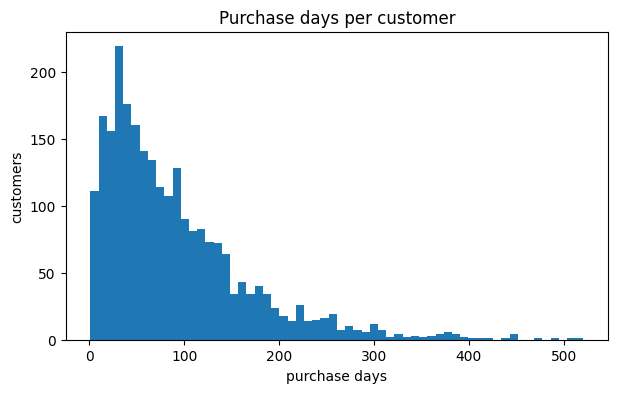

Loaded NPD transformer from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/global_transformer
NPD transformer input_length=12
NPD transformer output_horizon=5
Customers with ≥13 purchase days: 2333 / 2500


{'config': {'forecast_horizon': 5,
  'direct_output_horizon': 5,
  'min_purchase_days': 20,
  'window_size': 12,
  'n_clusters': 4,
  'test_customer_frac': 0.2,
  'transformer_epochs': 50,
  'transformer_size_layer': 128,
  'transformer_embedded_size': 128,
  'transformer_num_heads': 8,
  'transformer_dropout': 0.1,
  'transformer_batch_size': 32,
  'transformer_lr': 0.001,
  'transformer_module_path': '/Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/src/transformer_forecaster.py',
  'seed': 42},
 'n_eligible_customers': 2198,
 'n_train_customers': 1758,
 'n_test_customers': 440,
 'cluster_ids_trained': [0, 1, 2, 3],
 'case_customers': {'low_frequency': '610', 'high_frequency': '1510'},
 'global_transformer': {'avg_mae': 8.29153483506718,
  'avg_rmse': 11.545185384784823,
  'avg_history_len': 90.99090909090908,
  'n_customers': 440},
 'clustered_transformer': {'avg_mae': 8.465551422199356,
  'avg_rmse': 11.888448541714904,
  'avg_history_len'

Loaded NPD MAE (days): 8.29153483506718
Loaded NPD RMSE (days): 11.545185384784823


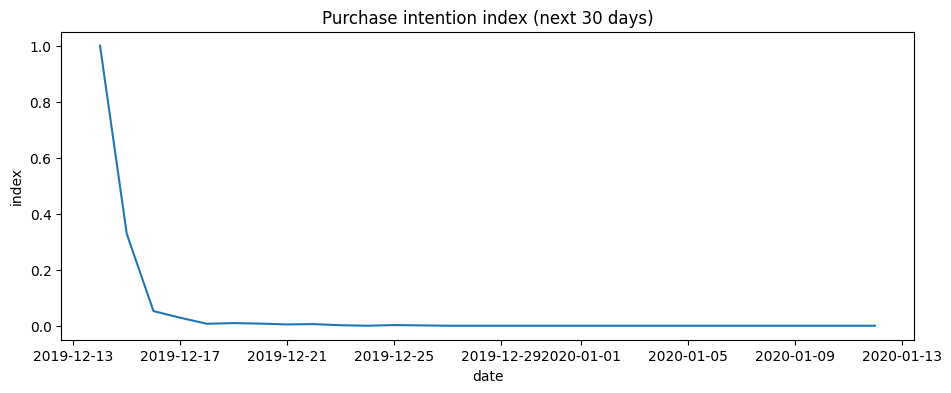

NPD timing alpha (auto): 0.00 (npd_mae=8.29153483506718)


In [4]:
# Quick readiness plot: purchase-days per customer
purchase_days = (tx.groupby([CUST_COL, DATE_COL]).size()
                   .reset_index(name='n_lines')
                   .groupby(CUST_COL).size())

plt.figure(figsize=(7,4))
plt.hist(purchase_days.values, bins=60)
plt.title('Purchase days per customer')
plt.xlabel('purchase days'); plt.ylabel('customers')
plt.show()

# Load externally trained Transformer-based NPD model
NPD_ARTIFACT_ROOT = REPO_ROOT / 'artifacts' / 'models' / 'npd_transformer_bundle'
NPD_GLOBAL_MODEL_DIR = NPD_ARTIFACT_ROOT / 'global_transformer'
NPD_TRAINING_SUMMARY_PATH = NPD_ARTIFACT_ROOT / 'training_summary.json'

if not NPD_GLOBAL_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Missing {NPD_GLOBAL_MODEL_DIR}. Run train-npd.ipynb first to train and export the external NPD forecaster."
    )

try:
    from src.transformer_forecaster import NPDTransformerForecaster
except Exception:
    from transformer_forecaster import NPDTransformerForecaster

npd_model = NPDTransformerForecaster.load(NPD_GLOBAL_MODEL_DIR)
npd_input_length = int(getattr(npd_model, "input_length", 5))
npd_min_events = npd_input_length + 1

npd = NPDModel(k=npd_input_length, min_events=npd_min_events, horizon=HORIZON)

print("Loaded NPD transformer from:", NPD_GLOBAL_MODEL_DIR)
print(f"NPD transformer input_length={npd_input_length}")
print(f"NPD transformer output_horizon={getattr(npd_model, 'output_horizon', 1)}")

print(f'Customers with ≥{npd_min_events} purchase days:', int((purchase_days >= npd_min_events).sum()), '/', len(purchase_days))

npd_summary = {}
if NPD_TRAINING_SUMMARY_PATH.exists():
    npd_summary = json.loads(NPD_TRAINING_SUMMARY_PATH.read_text(encoding='utf-8'))
    display(npd_summary)
else:
    print("Warning: training_summary.json not found, so DIF-PI will use a conservative timing weight.")

global_payload = npd_summary.get('global_transformer', {}) if isinstance(npd_summary, dict) else {}
npd_mae = float(global_payload.get('avg_mae')) if 'avg_mae' in global_payload else np.nan
npd_rmse = float(global_payload.get('avg_rmse')) if 'avg_rmse' in global_payload else np.nan

if np.isfinite(npd_mae):
    print('Loaded NPD MAE (days):', npd_mae)
if np.isfinite(npd_rmse):
    print('Loaded NPD RMSE (days):', npd_rmse)

t0, intent = npd.intention_index(tx, npd_model, cust_col=CUST_COL, date_col=DATE_COL)
plt.figure(figsize=(11,4))
plt.plot(intent.index, intent.values)
plt.title('Purchase intention index (next 30 days)')
plt.xlabel('date'); plt.ylabel('index')
plt.show()

# Automatic NPD reliability gate for timing influence
NPD_ALPHA = npd.alpha_from_mae(npd_mae) if np.isfinite(npd_mae) else 0.0
print(f"NPD timing alpha (auto): {NPD_ALPHA:.2f} (npd_mae={npd_mae if np.isfinite(npd_mae) else 'missing'})")

## 3) Executive case study selection and run


In [5]:
sku_stats = []
for sku, g in panel.groupby(SKU_COL):
    g = g.sort_values(TIME_COL).copy()
    history_days = len(g[TIME_COL].unique())
    demand_vals = g[DEMAND_COL].astype(float).values
    price_vals = g[PRICE_COL].astype(float).values
    nonzero_days = int((demand_vals > 0).sum())
    active_day_ratio = float(nonzero_days / max(history_days, 1))
    zero_share = float(1.0 - active_day_ratio)
    price_change_count = int(np.sum(np.abs(np.diff(price_vals)) > 1e-9)) if len(price_vals) > 1 else 0

    nz = demand_vals[demand_vals > 0]
    nz_mean = float(np.mean(nz)) if len(nz) else np.nan
    nz_std = float(np.std(nz)) if len(nz) else np.nan
    nz_cv = float(nz_std / (nz_mean + 1e-9)) if len(nz) else np.nan

    valid_corr = np.isfinite(price_vals) & np.isfinite(demand_vals)
    if valid_corr.sum() >= 3 and np.nanstd(price_vals[valid_corr]) > 1e-12 and np.nanstd(demand_vals[valid_corr]) > 1e-12:
        price_demand_corr = float(np.corrcoef(price_vals[valid_corr], demand_vals[valid_corr])[0, 1])
    else:
        price_demand_corr = np.nan

    # Lightweight log-log elasticity proxy for case selection only
    pos = (price_vals > 0) & (demand_vals > 0)
    if int(pos.sum()) >= 10 and np.nanstd(np.log(price_vals[pos])) > 1e-8:
        try:
            beta = float(np.polyfit(np.log(price_vals[pos]), np.log(demand_vals[pos]), 1)[0])
        except Exception:
            beta = np.nan
    else:
        beta = np.nan

    sku_stats.append({
        'StockCode': str(sku),
        'history_days': int(history_days),
        'nonzero_days': int(nonzero_days),
        'active_day_ratio': active_day_ratio,
        'zero_share': zero_share,
        'price_change_count': int(price_change_count),
        'nonzero_demand_cv': nz_cv,
        'price_demand_corr': price_demand_corr,
        'elasticity_proxy': beta,
    })

sku_stats = pd.DataFrame(sku_stats).sort_values(['nonzero_days', 'history_days'], ascending=False).reset_index(drop=True)

def _eligible(stats: pd.DataFrame, min_hist: int, min_nz: int) -> pd.DataFrame:
    return stats[(stats['history_days'] >= int(min_hist)) & (stats['nonzero_days'] >= int(min_nz))].copy()

# Choose thresholds
n_total = len(sku_stats)
min_hist, min_nz = MIN_HISTORY_DAYS_STRICT, MIN_NONZERO_DAYS_STRICT

if ELIGIBILITY_MODE == "strict":
    pass
elif ELIGIBILITY_MODE == "relaxed":
    min_hist, min_nz = MIN_HISTORY_DAYS_RELAXED, MIN_NONZERO_DAYS_RELAXED
elif ELIGIBILITY_MODE == "adaptive":
    # Stepwise relaxation to reach target fraction.
    # (Keeps minimums above the forecast horizon so scenario+windowing remains meaningful).
    steps = [
        (MIN_HISTORY_DAYS_STRICT, MIN_NONZERO_DAYS_STRICT),
        (270, 45),
        (180, 30),
        (120, 25),
        (90, 20),
        (60, 15),
    ]
    # Guard: don't allow history < 2*seq_len for transformer-based parts
    min_hist_floor = max(2 * TRANSFORMER_SEQ_LEN, HORIZON + 30)
    min_nz_floor = max(HORIZON, 10)

    chosen = None
    for h, nz in steps:
        h2 = max(int(h), int(min_hist_floor))
        nz2 = max(int(nz), int(min_nz_floor))
        cand = _eligible(sku_stats, h2, nz2)
        if len(cand) / max(n_total, 1) >= float(TARGET_ELIGIBLE_FRACTION):
            chosen = (h2, nz2, cand)
            break
    if chosen is None:
        # Fall back to the loosest step.
        h, nz = steps[-1]
        h2 = max(int(h), int(min_hist_floor))
        nz2 = max(int(nz), int(min_nz_floor))
        chosen = (h2, nz2, _eligible(sku_stats, h2, nz2))

    min_hist, min_nz, eligible = chosen
else:
    raise ValueError(f"Unknown ELIGIBILITY_MODE: {ELIGIBILITY_MODE!r}")

if 'eligible' not in locals():
    eligible = _eligible(sku_stats, min_hist, min_nz)

print(f"Eligibility mode: {ELIGIBILITY_MODE}")
print(f"Thresholds used: MIN_HISTORY_DAYS={min_hist}, MIN_NONZERO_DAYS={min_nz}")
print('Eligible SKUs:', len(eligible), '/', len(sku_stats))

# (Optional) quick distribution summary for tuning
display(sku_stats.describe(percentiles=[.1, .25, .5, .75, .9]))

if len(eligible) == 0:
    raise ValueError('No SKU meets thresholds. Relax thresholds or increase the SKU pool in the EDA export.')

eligible_skus = eligible['StockCode'].astype(str).tolist()

def _load_series_list(path_obj):
    path_obj = Path(path_obj)
    if not path_obj.exists():
        return None
    try:
        s = pd.read_csv(path_obj).iloc[:, 0].astype(str).dropna().tolist()
        return [str(x) for x in s if str(x) != 'nan']
    except Exception:
        return None

# Prefer a saved split used by the other validation notebooks
split_train = None
split_test = None
split_candidates = [
    (OUT_DIR / 'train_skus.csv', OUT_DIR / 'test_skus.csv'),
    (GLOBAL_FORECASTER_DIR / 'train_skus.csv', GLOBAL_FORECASTER_DIR / 'test_skus.csv'),
    (REPO_ROOT / 'artifacts' / 'models' / 'train_skus.csv', REPO_ROOT / 'artifacts' / 'models' / 'test_skus.csv'),
]
for train_path, test_path in split_candidates:
    tr = _load_series_list(train_path)
    te = _load_series_list(test_path)
    if tr and te:
        tr = [s for s in tr if s in eligible_skus]
        te = [s for s in te if s in eligible_skus]
        if len(tr) > 0 and len(te) > 0:
            split_train, split_test = tr, te
            print(f'Loaded saved SKU split from: {train_path.parent}')
            break

if split_train is not None and split_test is not None:
    TRAIN_SKUS = split_train
    TEST_SKUS = split_test
else:
    # SKU holdout split (TRAIN_SKUS / TEST_SKUS)
    if SKU_HOLDOUT_ENABLED and len(eligible_skus) >= 2:
        rng = np.random.default_rng(SPLIT_SEED)
        rng.shuffle(eligible_skus)
        n_test = max(1, int(round(len(eligible_skus) * float(TEST_SKU_FRAC))))
        TEST_SKUS = eligible_skus[:n_test]
        TRAIN_SKUS = eligible_skus[n_test:]
    else:
        TRAIN_SKUS = eligible_skus
        TEST_SKUS = eligible_skus

print(f"Eligible SKUs: {len(eligible_skus)} | Train SKUs: {len(TRAIN_SKUS)} | Test SKUs: {len(TEST_SKUS)}")

case_candidates = eligible[eligible['StockCode'].astype(str).isin([str(x) for x in TEST_SKUS])].copy().reset_index(drop=True)
if len(case_candidates) == 0:
    raise ValueError('No TEST_SKUs available for executive case selection.')

def _rank01(series, ascending=True):
    s = pd.Series(series).astype(float)
    if s.isna().all():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s.rank(method='average', pct=True, ascending=ascending).fillna(0.0)

case_candidates['regular_score'] = (
    0.50 * _rank01(case_candidates['active_day_ratio'], ascending=True) +
    0.25 * _rank01(case_candidates['history_days'], ascending=True) +
    0.15 * _rank01(-case_candidates['nonzero_demand_cv'].fillna(case_candidates['nonzero_demand_cv'].median()), ascending=True) +
    0.10 * _rank01(case_candidates['price_change_count'], ascending=True)
)

case_candidates['intermittent_score'] = (
    0.55 * _rank01(case_candidates['zero_share'], ascending=True) +
    0.25 * _rank01(case_candidates['history_days'], ascending=True) +
    0.10 * _rank01(case_candidates['price_change_count'], ascending=True) +
    0.10 * _rank01(case_candidates['nonzero_days'], ascending=True)
)

elasticity_strength = (-case_candidates['elasticity_proxy']).where(case_candidates['elasticity_proxy'] < 0, 0.0)
corr_strength = (-case_candidates['price_demand_corr']).where(case_candidates['price_demand_corr'] < 0, 0.0)
case_candidates['price_sensitive_score'] = (
    0.40 * _rank01(elasticity_strength.fillna(0.0), ascending=True) +
    0.30 * _rank01(corr_strength.fillna(0.0), ascending=True) +
    0.20 * _rank01(case_candidates['price_change_count'], ascending=True) +
    0.10 * _rank01(case_candidates['active_day_ratio'], ascending=True)
)

SKU_REG = str(case_candidates.sort_values(['regular_score', 'active_day_ratio'], ascending=False).iloc[0]['StockCode'])
SKU_INT = str(case_candidates.sort_values(['intermittent_score', 'zero_share'], ascending=False).iloc[0]['StockCode'])

SKU_PS = str(case_candidates.sort_values(['price_sensitive_score', 'price_change_count'], ascending=False).iloc[0]['StockCode'])

case_role_rows = [
    {'regime': 'regular', 'sku': SKU_REG},
    {'regime': 'intermittent', 'sku': SKU_INT},
    {'regime': 'price_sensitive', 'sku': SKU_PS},
]
case_study_selection_summary = pd.DataFrame(case_role_rows).merge(
    case_candidates,
    left_on='sku',
    right_on='StockCode',
    how='left'
)

CASE_SKU_SUGGESTED = {
    'regular': SKU_REG,
    'intermittent': SKU_INT,
    'price_sensitive': SKU_PS,
}

if CASE_SKU_OVERRIDE not in (None, "", "None"):
    CASE_SKU = str(CASE_SKU_OVERRIDE)
else:
    CASE_SKU = str(CASE_SKU_SUGGESTED.get(str(CASE_REGIME_SELECTION).strip().lower(), SKU_PS))

print("Suggested case-study SKUs:", CASE_SKU_SUGGESTED)
print("CASE_SKU selected:", CASE_SKU)

display(
    case_candidates[
        ['StockCode', 'history_days', 'nonzero_days', 'active_day_ratio', 'zero_share',
         'price_change_count', 'nonzero_demand_cv', 'price_demand_corr', 'elasticity_proxy',
         'regular_score', 'intermittent_score', 'price_sensitive_score']
    ].sort_values(['price_sensitive_score', 'regular_score', 'intermittent_score'], ascending=False).reset_index(drop=True)
)

display(case_study_selection_summary[['regime', 'sku', 'history_days', 'nonzero_days', 'active_day_ratio',
                                      'zero_share', 'price_change_count', 'price_demand_corr',
                                      'elasticity_proxy']])

if EXPORT_SKU_SPLIT_LISTS:
    pd.Series(TRAIN_SKUS, name="train_sku").to_csv(OUT_DIR / "train_skus.csv", index=False)
    pd.Series(TEST_SKUS, name="test_sku").to_csv(OUT_DIR / "test_skus.csv", index=False)

case_candidates.to_csv(OUT_DIR / "case_study_candidate_skus.csv", index=False)
case_study_selection_summary.to_csv(OUT_DIR / "case_study_selection_summary.csv", index=False)

Eligibility mode: adaptive
Thresholds used: MIN_HISTORY_DAYS=365, MIN_NONZERO_DAYS=60
Eligible SKUs: 300 / 300


,history_days,nonzero_days,active_day_ratio,zero_share,price_change_count,nonzero_demand_cv,price_demand_corr,elasticity_proxy
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,698.776667,506.603333,0.723673,0.276327,239.313333,0.813563,-0.223473,-1.011323
std,27.370127,127.896590,0.177071,0.177071,191.541891,0.206307,0.209986,1.215514
min,480.000000,112.000000,0.163743,0.002817,4.000000,0.344399,-0.781740,-6.713971
10%,690.000000,340.300000,0.480633,0.052074,25.000000,0.600457,-0.518401,-2.306849
25%,700.000000,421.250000,0.608665,0.149484,102.000000,0.675772,-0.381789,-1.748280
50%,706.000000,530.500000,0.757234,0.242766,178.000000,0.770547,-0.182218,-1.044459
75%,709.000000,599.250000,0.850516,0.391335,356.750000,0.928844,-0.065602,-0.255481
90%,710.000000,669.200000,0.947926,0.519367,558.100000,1.110578,0.020136,0.149697
max,711.000000,708.000000,0.997183,0.836257,707.000000,1.665961,0.359502,6.250117


Loaded saved SKU split from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/difpi_exec_demo
Eligible SKUs: 300 | Train SKUs: 240 | Test SKUs: 60
Suggested case-study SKUs: {'regular': '1082185', 'intermittent': '9553031', 'price_sensitive': '908531'}
CASE_SKU selected: 1082185


,StockCode,history_days,nonzero_days,active_day_ratio,zero_share,price_change_count,nonzero_demand_cv,price_demand_corr,elasticity_proxy,regular_score,intermittent_score,price_sensitive_score
0,908531,708,661,0.933616,0.066384,537,0.987326,-0.689760,-3.228634,0.708333,0.432500,0.955000
1,909894,701,627,0.894437,0.105563,264,0.940004,-0.574196,-2.305235,0.591250,0.355417,0.895000
2,981760,711,705,0.991561,0.008439,613,0.714006,-0.431304,-1.850406,0.911250,0.451667,0.892500
3,1068719,711,671,0.943741,0.056259,381,0.879691,-0.368018,-1.825884,0.795417,0.483750,0.826667
4,12810393,480,370,0.770833,0.229167,368,0.799480,-0.493647,-1.772389,0.407500,0.366667,0.803333
5,896369,710,533,0.750704,0.249296,168,1.042147,-0.447229,-1.911758,0.538333,0.605833,0.783333
6,1094955,708,465,0.656780,0.343220,230,0.830979,-0.430119,-1.907069,0.483333,0.624167,0.778333
7,1065593,708,677,0.956215,0.043785,174,0.680431,-0.202224,-2.222496,0.781667,0.376667,0.771667
8,5569374,709,392,0.552891,0.447109,107,1.346696,-0.462480,-2.399917,0.364167,0.666667,0.755000
9,1106523,711,705,0.991561,0.008439,689,0.532380,-0.300128,-0.965527,0.966250,0.456667,0.727500


,regime,sku,history_days,nonzero_days,active_day_ratio,zero_share,price_change_count,price_demand_corr,elasticity_proxy
0,regular,1082185,711,708,0.995781,0.004219,707,-0.188070,-0.354948
1,intermittent,9553031,711,325,0.457103,0.542897,69,-0.076397,-0.773835
2,price_sensitive,908531,708,661,0.933616,0.066384,537,-0.689760,-3.228634


,StockCode,regime,sparsity,active_day_ratio,price_change_rate,price_demand_corr,intervention_responsiveness
0,1082185,regular,0.004219,0.995781,0.994374,-0.188070,0.696876
1,9553031,intermittent,0.542897,0.457103,0.097046,-0.076397,0.099332
2,908531,price_sensitive,0.066384,0.933616,0.758475,-0.689760,0.854281


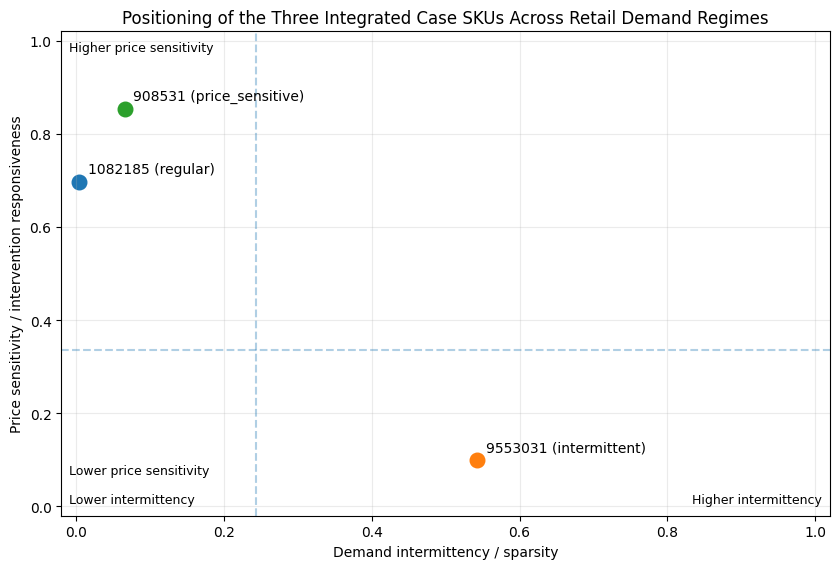

/Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/difpi_exec_demo/positioning_of_the_three_integrated_case_skus_across_retail_demand_regimes.png


In [6]:
# Positioning of the Three Integrated Case SKUs Across Retail Demand Regimes

def _compute_regime_features(sku_df: pd.DataFrame) -> dict:
    sku_df = sku_df.copy()
    sku_df[TIME_COL] = pd.to_datetime(sku_df[TIME_COL])
    sku_df = sku_df.sort_values(TIME_COL)

    demand = pd.to_numeric(sku_df[DEMAND_COL], errors="coerce").fillna(0.0)
    price = pd.to_numeric(sku_df[PRICE_COL], errors="coerce")

    # x-axis: intermittency / sparsity
    active_day_ratio = float((demand > 0).mean()) if len(demand) else np.nan
    sparsity = 1.0 - active_day_ratio if pd.notna(active_day_ratio) else np.nan

    # price-change readiness
    valid_prev = price.shift(1).notna() & (price.shift(1) > 0)
    rel_price_change = ((price - price.shift(1)) / price.shift(1)).where(valid_prev)
    price_change_rate = float((rel_price_change.abs() > 1e-12).mean()) if len(price) > 1 else 0.0

    # negative price-demand association strength
    valid_corr = price.notna() & demand.notna()
    corr = np.nan
    if valid_corr.sum() >= 3 and price[valid_corr].nunique() > 1 and demand[valid_corr].nunique() > 1:
        corr = float(price[valid_corr].corr(demand[valid_corr]))
    neg_corr_strength = max(0.0, -corr) if pd.notna(corr) else 0.0

    # raw intervention-responsiveness proxy:
    # combines observed negative price-demand association with actual price movement
    intervention_raw = 0.5 * neg_corr_strength + 0.5 * price_change_rate

    return {
        "active_day_ratio": active_day_ratio,
        "sparsity": sparsity,
        "price_change_rate": price_change_rate,
        "price_demand_corr": corr,
        "neg_corr_strength": neg_corr_strength,
        "intervention_raw": intervention_raw,
    }

# Build regime features for the whole SKU pool so the selected SKUs are positioned in context
panel_for_plot = panel.copy()
panel_for_plot[SKU_COL] = panel_for_plot[SKU_COL].astype(str)

all_rows = []
for sku, sku_df in panel_for_plot.groupby(SKU_COL, sort=False):
    feats = _compute_regime_features(sku_df)
    feats[SKU_COL] = sku
    all_rows.append(feats)

sku_regime_df = pd.DataFrame(all_rows)

# Normalize intervention responsiveness to [0, 1] across the available SKU pool
raw = sku_regime_df["intervention_raw"].astype(float)
raw_min, raw_max = raw.min(), raw.max()
if pd.notna(raw_min) and pd.notna(raw_max) and raw_max > raw_min:
    sku_regime_df["intervention_responsiveness"] = (raw - raw_min) / (raw_max - raw_min)
else:
    sku_regime_df["intervention_responsiveness"] = 0.5

# Pull only the suggested case-study SKUs from CASE_SKU_SUGGESTED
selected_case_df = (
    pd.DataFrame(
        [{"regime": regime, SKU_COL: str(sku)} for regime, sku in CASE_SKU_SUGGESTED.items()]
    )
    .merge(sku_regime_df, on=SKU_COL, how="left")
)

display(selected_case_df[[SKU_COL, "regime", "sparsity", "active_day_ratio",
                          "price_change_rate", "price_demand_corr",
                          "intervention_responsiveness"]])

fig, ax = plt.subplots(figsize=(8.5, 5.8))

# Median guides across the full SKU pool for visual context
x_med = float(sku_regime_df["sparsity"].median())
y_med = float(sku_regime_df["intervention_responsiveness"].median())
ax.axvline(x_med, linestyle="--", alpha=0.35)
ax.axhline(y_med, linestyle="--", alpha=0.35)

for _, row in selected_case_df.iterrows():
    x = row["sparsity"]
    y = row["intervention_responsiveness"]
    sku = row[SKU_COL]
    regime = row["regime"]

    ax.scatter(x, y, s=110)
    ax.annotate(
        f"{sku} ({regime})",
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_title("Positioning of the Three Integrated Case SKUs Across Retail Demand Regimes")
ax.set_xlabel("Demand intermittency / sparsity")
ax.set_ylabel("Price sensitivity / intervention responsiveness")

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.25)

ax.text(0.01, 0.02, "Lower intermittency", transform=ax.transAxes, ha="left", va="bottom", fontsize=9)
ax.text(0.99, 0.02, "Higher intermittency", transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
ax.text(0.01, 0.98, "Higher price sensitivity", transform=ax.transAxes, ha="left", va="top", fontsize=9)
ax.text(0.01, 0.08, "Lower price sensitivity", transform=ax.transAxes, ha="left", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

plot_path = OUT_DIR / "positioning_of_the_three_integrated_case_skus_across_retail_demand_regimes.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print(plot_path)

### 3.1 Build continuous daily series

Decision date: 2019-11-13 | Train days: 681 | Test days: 30


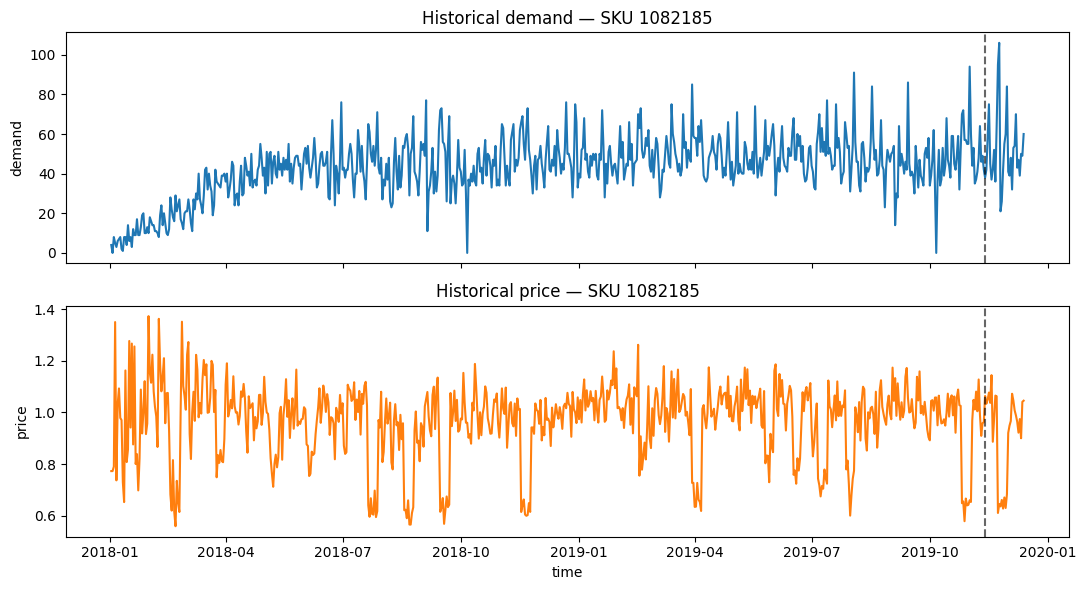

corr(price, demand): -0.188070424718749


In [7]:
sku_df = panel[panel[SKU_COL].astype(str) == str(CASE_SKU)].copy()
sku_df = sku_df.sort_values(TIME_COL).set_index(TIME_COL)

# Daily reindex
full = pd.date_range(sku_df.index.min(), sku_df.index.max(), freq='D')
sku_df = sku_df.reindex(full)
sku_df.index.name = TIME_COL

sku_df[PRICE_COL] = sku_df[PRICE_COL].ffill()
sku_df[DEMAND_COL] = sku_df[DEMAND_COL].fillna(0.0)

sku_df = sku_df.reset_index()

# Time split (train/test) for this SKU
# Decision date is the last date before the evaluation horizon.
# All model fitting (elasticity, forecasters, surrogate) must use TRAIN only.
DECISION_DATE = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
sku_df_train = sku_df[sku_df[TIME_COL] <= DECISION_DATE].copy()
sku_df_test  = sku_df[sku_df[TIME_COL] >  DECISION_DATE].copy()

print(f"Decision date: {DECISION_DATE.date()} | Train days: {len(sku_df_train)} | Test days: {len(sku_df_test)}")
if len(sku_df_test) < HORIZON:
    print("Warning: test segment shorter than HORIZON; consider increasing history or reducing HORIZON.")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(sku_df[TIME_COL], sku_df[DEMAND_COL], color='tab:blue')
axes[0].set_title(f'Historical demand — SKU {CASE_SKU}')
axes[0].set_ylabel('demand')
axes[0].axvline(DECISION_DATE, color='black', linestyle='--', alpha=0.6)

axes[1].plot(sku_df[TIME_COL], sku_df[PRICE_COL], color='tab:orange')
axes[1].set_title(f'Historical price — SKU {CASE_SKU}')
axes[1].set_xlabel('time')
axes[1].set_ylabel('price')
axes[1].axvline(DECISION_DATE, color='black', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(OUT_DIR / f'historical_demand_and_price_case_sku_{CASE_SKU}.png', dpi=160, bbox_inches='tight')
plt.show()

corr = np.corrcoef(sku_df[PRICE_COL].values.astype(float), sku_df[DEMAND_COL].values.astype(float))[0,1]
print('corr(price, demand):', float(corr))

## 4) Demand preparation

The train demand series is used directly in the downstream DIF-PI experiments.


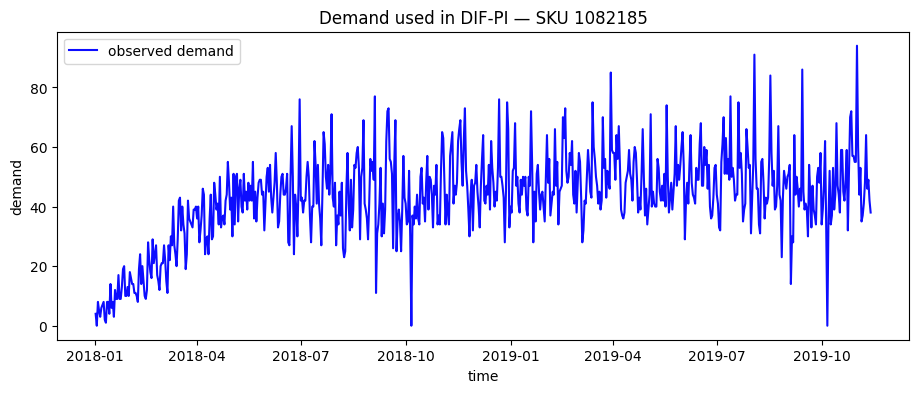

In [8]:
# Demand preparation
# Use the observed CASE_SKU train demand directly and keep a compatible interface
# for the downstream DIF-PI cells.

# Choose demand series for scenario generation

base_price = sku_df_train[PRICE_COL].values.astype(float)
base_demand = sku_df_train[DEMAND_COL].values.astype(float)
time_train = pd.to_datetime(sku_df_train[TIME_COL]).values

plt.figure(figsize=(11, 4))
plt.plot(time_train, base_demand, label="observed demand", color="blue", alpha=0.95)
plt.title(f"Demand used in DIF-PI — SKU {CASE_SKU}")
plt.xlabel("time")
plt.ylabel("demand")
plt.legend()
plt.show()

## 5) What-If scenario generation

The core decision pipeline:

1) Elasticity estimation (TBWISA)
   - Uses a controlled, zero-safe, robust estimator (Huber).  
   - Uses event-based fitting (price-change days) to improve identifiability.  
2) Scenario generation across `DELTAS_PCT`  
3) Demand forecasting with the pretrained global transformer (`scenario_gen_transformer_global`)  
4) Revenue and optimal window** selection


In [9]:
# Forecast backend
try:
    from src.transformer_forecaster import ScenarioGenerationTransformerForecaster
    _tf_ok = True
except Exception as e:
    _tf_ok = False
    print('ScenarioGenerationTransformerForecaster is unavailable; fallback to ARIMA. Error:', e)

class ARIMAForecaster:
    def __init__(self, order=(1,1,1)):
        self.order = order
    def forecast(self, history, horizon):
        history = np.asarray(history, dtype=float)
        if len(history) < 10:
            return np.repeat(history[-1] if len(history) else 0.0, horizon)
        res = SARIMAX(history, order=self.order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return np.asarray(res.forecast(steps=horizon))

_global_sg_forecaster = None

def fit_forecaster(y_hist):
    """Return the forecasting backend.

    Loads a pre-trained global model from GLOBAL_FORECASTER_DIR.
    Otherwise falls back to ARIMA.
    """
    y_hist = np.asarray(y_hist, float)

    if _tf_ok:
        global _global_sg_forecaster
        if _global_sg_forecaster is None:
            if not Path(GLOBAL_FORECASTER_DIR).exists():
                raise FileNotFoundError(
                    f"Missing global forecaster directory: {GLOBAL_FORECASTER_DIR}. "
                    "Run train_global_scenario_forecaster.ipynb first."
                )
            _global_sg_forecaster = ScenarioGenerationTransformerForecaster.load(GLOBAL_FORECASTER_DIR)
        return _global_sg_forecaster, 'scenario_gen_transformer_global'

    return ARIMAForecaster(order=(1,1,1)), 'arima'

def revenue(price, demand):
    return TBWISAGenerator().revenue(price, demand)

def best_window(rev, min_len=7, max_len=30, length_penalty=0.0):
    tb = TBWISAGenerator()
    if hasattr(tb, 'find_optimal_window_with_demand'):
        return tb.find_optimal_window_with_demand(
            rev,
            demand=None,
            penalty_factor=length_penalty,
            demand_weight=0.0,
            min_window_size=min_len,
            max_window_size=max_len
        )
    return tb.best_window(rev, min_len=min_len, max_len=max_len, length_penalty=length_penalty)


# TBWISA uses log() internally => strictly positive demand
tbwisa_input = pd.DataFrame({
    PRICE_COL: np.clip(base_price, 1e-9, None),
    DEMAND_COL: np.clip(base_demand, 1e-9, None)
})

# Train log baselines on positive rows
train_df = tbwisa_input[(tbwisa_input[PRICE_COL] > 0) & (tbwisa_input[DEMAND_COL] > 0)].copy()
if len(train_df) < MIN_POS_ROWS_LOGMODELS:
    raise ValueError(f'Not enough positive rows for log models: {len(train_df)} < {MIN_POS_ROWS_LOGMODELS}')

tbwisa = TBWISAGenerator()

# Controlled elasticity (trend + seasonality + lag) + non-positive prior
# This replaces the naive log-log fit with a controlled regression:
# log(demand_t) ~ beta*log(price_t) + trend + seasonality + lag(log(demand_{t-1}))
# Then enforces beta <= 0 (with epsilon) to respect basic economic priors for normal goods.
ELAST_PRIOR_EPS = 0.05              # configurable (e.g., 0.01..0.10)
SEASONAL_PERIODS = (7.0, 365.25)    # daily weekly + annual
USE_CONTROLLED_ELASTICITY = True
ELAST_MAX_ABS = 4.0                 # optional cap on |elasticity| (set None to disable)
HUBER_EPSILON = 1.35                # HuberRegressor epsilon
HUBER_ALPHA = 1e-4                  # HuberRegressor L2 regularization
MIN_FIT_ROWS = 30                   # minimum positive rows (with lag) for robust log fit
USE_EVENT_BASED_ELASTICITY = True   # fit elasticity only on price-change days when possible
PRICE_CHANGE_PCT_THRESH = 0.01      # 1% price move threshold for event-based fitting


def _controlled_elasticity(price_s, demand_s, seasonal_periods=SEASONAL_PERIODS, eps=1e-9, prior_eps=ELAST_PRIOR_EPS,
                           use_event=USE_EVENT_BASED_ELASTICITY, price_change_pct_thresh=PRICE_CHANGE_PCT_THRESH,
                           elast_max_abs=None, huber_epsilon=1.35, huber_alpha=1e-4, min_fit_rows=30):
    """Estimate a controlled price elasticity using a robust, zero-safe regression.

    Zero-safe: fits only on rows with demand>0 and lag(demand)>0 (true zero sales are excluded from the log fit).
    Robust: uses HuberRegressor to reduce sensitivity to demand spikes/outliers.
    Controls: trend + Fourier seasonality + lagged log-demand.
    Prior: enforces non-positive elasticity (beta <= -prior_eps).
    Optional cap: limits |beta| by setting beta >= -elast_max_abs when elast_max_abs is not None.
    """
    p = np.asarray(price_s, float)
    d = np.asarray(demand_s, float)
    n = int(min(len(p), len(d)))
    if n < 5:
        beta_raw = 0.0
        beta = -abs(float(prior_eps))
        intercept = float(np.log(np.clip(np.mean(d) if n else 1.0, eps, None)))
        resid = np.zeros(n, dtype=float)
        meta = {'beta_raw': beta_raw, 'beta_final': beta, 'intercept': intercept, 'r2': np.nan, 'n_fit': 0, 'clipped': False,
                'event_used': False, 'n_fit_event': None, 'price_change_pct_thresh': float(price_change_pct_thresh) if 'price_change_pct_thresh' in locals() else None}
        return beta, intercept, resid, meta

    # Build supervised rows (t>=1) with a valid lag and strictly positive demand (zero-safe)
    idx = np.arange(1, n)
    mask_base = (p[idx] > 0) & (d[idx] > 0) & (d[idx-1] > 0)

    # Optional: event-based fitting (focus on periods where price actually changes)
    event_used = False
    n_fit_event = None
    if bool(use_event):
        # log threshold corresponding to pct change (e.g., 1% -> ~0.00995)
        thr = float(np.log1p(float(price_change_pct_thresh)))
        dlogp = np.abs(np.log(np.clip(p[idx], eps, None)) - np.log(np.clip(p[idx-1], eps, None)))
        mask_event = mask_base & (dlogp >= thr)
        n_fit_event = int(mask_event.sum())
        if n_fit_event >= int(min_fit_rows):
            mask = mask_event
            event_used = True
        else:
            mask = mask_base
    else:
        mask = mask_base

    if int(mask.sum()) < int(min_fit_rows):
        # Not enough usable rows -> return a conservative tiny negative elasticity
        beta_raw = 0.0
        beta = -abs(float(prior_eps))
        intercept = float(np.log(np.clip(np.mean(d[d>0]) if np.any(d>0) else 1.0, eps, None)))
        x_all = np.log(np.clip(p[:n], eps, None))
        y_all = np.log(np.clip(d[:n], eps, None))
        resid = (y_all - (intercept + beta * x_all)).astype(float)
        resid[0] = resid[1] if n > 1 else 0.0
        meta = {'beta_raw': beta_raw, 'beta_final': beta, 'intercept': intercept, 'r2': np.nan, 'n_fit': int(mask.sum()), 'clipped': False, 'fallback': 'min_fit_rows',
                'event_used': bool(event_used), 'n_fit_event': n_fit_event, 'price_change_pct_thresh': float(price_change_pct_thresh)}
        return beta, intercept, resid, meta

    # Prepare regressors on masked rows
    p_t = p[idx][mask]
    d_t = d[idx][mask]
    d_lag = d[idx-1][mask]
    t = np.arange(n, dtype=float)
    t_t = t[idx][mask]

    y_t = np.log(d_t)
    x_price = np.log(p_t)

    # trend (z-scored)
    trend = (t_t - t_t.mean()) / (t_t.std() if t_t.std() > 0 else 1.0)

    cols = {'log_price': x_price, 'trend_z': trend}

    # seasonality via Fourier terms on index (works without explicit datetime)
    for per in seasonal_periods:
        cols[f'sin_{per}'] = np.sin(2.0 * np.pi * t_t / per)
        cols[f'cos_{per}'] = np.cos(2.0 * np.pi * t_t / per)

    cols['lag_log_demand'] = np.log(d_lag)

    X_df = pd.DataFrame(cols)

    reg = HuberRegressor(epsilon=float(huber_epsilon), alpha=float(huber_alpha))
    reg.fit(X_df, y_t)

    beta_raw = float(reg.coef_[0])  # log_price
    intercept = float(reg.intercept_)

    y_hat = reg.predict(X_df)
    r2 = float(r2_score(y_t, y_hat))

    # Non-positive prior: beta <= -prior_eps
    beta = float(beta_raw)
    if beta >= 0:
        beta = -abs(float(prior_eps))

    clipped = False
    if elast_max_abs is not None:
        # cap magnitude: beta >= -elast_max_abs
        cap = -abs(float(elast_max_abs))
        if beta < cap:
            beta = cap
            clipped = True

    # Residuals used by TBWISA internals: keep length n
    # For true zeros, log(clip) yields a large negative; residuals remain finite and preserve near-zero baseline.
    x_all = np.log(np.clip(p[:n], eps, None))
    y_all = np.log(np.clip(d[:n], eps, None))
    resid = (y_all - (intercept + beta * x_all)).astype(float)
    resid[0] = resid[1] if n > 1 else 0.0

    meta = {
        'beta_raw': beta_raw,
        'beta_final': beta,
        'intercept': intercept,
        'r2': r2,
        'n_fit': int(mask.sum()),
        'clipped': clipped,
        'huber_epsilon': float(huber_epsilon),
        'huber_alpha': float(huber_alpha),
        'seasonal_periods': list(seasonal_periods)
    }
    return beta, intercept, resid, meta

import types
if USE_CONTROLLED_ELASTICITY:
    def _calc_elast(self, input, output):
        beta, icpt, resid, meta = _controlled_elasticity(input, output, elast_max_abs=ELAST_MAX_ABS, huber_epsilon=HUBER_EPSILON, huber_alpha=HUBER_ALPHA, min_fit_rows=MIN_FIT_ROWS)
        self._last_elasticity_meta = meta
        return beta, icpt, resid

    # Monkey-patch only this instance so we don't affect other notebooks/imports
    tbwisa.calculate_structural_elasticity = types.MethodType(_calc_elast, tbwisa)

    # Diagnostics for this SKU
    _b, _icpt, _resid = tbwisa.calculate_structural_elasticity(tbwisa_input[PRICE_COL], tbwisa_input[DEMAND_COL])
    _meta = getattr(tbwisa, '_last_elasticity_meta', {})
    print(f"TBWISA elasticity (controlled Huber, zero-safe): {_b:.6f} | raw={_meta.get('beta_raw', np.nan):.6f} | r2={_meta.get('r2', np.nan):.3f} | n_fit={_meta.get('n_fit', np.nan)} | clipped={_meta.get('clipped', False)} | prior_eps={ELAST_PRIOR_EPS}")

loglin = LogLinearScenarioGeneration()
xgb = XGBoostScenarioGeneration()
loglin.train(train_df, PRICE_COL, DEMAND_COL)
xgb.train(train_df, PRICE_COL, DEMAND_COL)

forecaster, backend = fit_forecaster(base_demand)
print('Forecast backend:', backend)


# Intention weighting (automatic reliability gating based on NPD MAE)
# intent_norm in [0,1] encodes relative purchase-intention over the horizon.
intent_norm = intent.values[:HORIZON].astype(float)
intent_norm = intent_norm / intent_norm.max() if intent_norm.max() > 0 else np.ones(HORIZON)

try:
    alpha = float(NPD_ALPHA)
except Exception:
    alpha = 0.0

# Blend with uniform weights to avoid distorting absolute levels; keep mean weight ≈ 1.0
intent_w = (1.0 - alpha) + alpha * intent_norm
intent_w = intent_w / (intent_w.mean() if intent_w.mean() > 0 else 1.0)

print(f"NPD timing enabled: {alpha > 0} | alpha={alpha:.2f} | npd_mae={float(npd_mae):.2f} days")

def forecast_with(history):
    return forecaster.forecast(np.asarray(history, float), HORIZON)

# Generate TBWISA scenarios (exclude baseline 0)
scen_in, scen_out = tbwisa.generate_scenarios(
    tbwisa_input, input_col=PRICE_COL, output_col=DEMAND_COL,
    price_change_percentages=[d for d in DELTAS_PCT if d != 0]
)

# Build scenario dict (TBWISA + baselines + baseline)
scenarios = {'tbwisa': {}, 'loglinear': {}, 'xgboost': {}}
scenarios['tbwisa'][0] = (base_price, base_demand)
scenarios['loglinear'][0] = (base_price, base_demand)
scenarios['xgboost'][0] = (base_price, base_demand)

# Price delta transform used throughout scenario evaluation and revenue computation.
# By definition: +delta_pct increases price (multiplicative uplift).
def apply_price_delta(price_hist, delta_pct):
    """Apply delta_pct to a price history vector."""
    return np.asarray(price_hist, float) * (1.0 + float(delta_pct)/100.0)

# Semantics derived from the transform above (used by X-TBWISA screening)
DELTA_SEMANTICS = "price_increase"  # +delta_pct -> higher price

for pct in [d for d in DELTAS_PCT if d != 0]:
    # Baseline transform used by non-TBWISA models (+delta => higher price)
    price_cf = apply_price_delta(base_price, pct)

    # TBWISA consistency fix
    # TBWISA returns counterfactual demand series that corresponds to a specific counterfactual price series.
    # Use TBWISA's generated price path if available; otherwise fall back to the baseline transform.
    key = f'{PRICE_COL} change {pct}%'
    try:
        price_tb = np.asarray(scen_in[key], float)
    except Exception:
        price_tb = price_cf

    try:
        demand_tb = np.asarray(scen_out[key], float)
    except Exception:
        # If TBWISA changes key formatting, fall back to the baseline demand.
        demand_tb = np.asarray(base_demand, float)

    # Quick check: does TBWISA price multiplier match the baseline transform?
    exp_mult = 1.0 + float(pct)/100.0
    tb_mult = float(np.nanmean(price_tb / np.clip(base_price, 1e-9, None)))
    if np.isfinite(tb_mult) and abs(tb_mult - exp_mult) > 1e-3:
        print(f'[warn] TBWISA price path for delta={pct}% implies multiplier ~{tb_mult:.4f} (expected ~{exp_mult:.4f}).')

    X = np.log(np.clip(price_cf, 1e-9, None)).reshape(-1, 1)
    demand_ll = np.exp(np.clip(loglin.model.predict(X), -50, 50)).astype(float)
    demand_xg = np.exp(np.clip(xgb.model.predict(X), -50, 50)).astype(float)

    scenarios['tbwisa'][pct] = (price_tb, demand_tb)
    scenarios['loglinear'][pct] = (price_cf, demand_ll)
    scenarios['xgboost'][pct] = (price_cf, demand_xg)

# Scenario summary (price and demand response)
_sanity = []
for pct in [d for d in DELTAS_PCT]:
    p_tb, d_tb = scenarios['tbwisa'][pct]
    p_ll, d_ll = scenarios['loglinear'][pct]
    _sanity.append({
        'delta_pct': int(pct),
        'tbwisa_last_price': float(np.asarray(p_tb, float)[-1]),
        'loglinear_last_price': float(np.asarray(p_ll, float)[-1]),
        'expected_price_multiplier': 1.0 + float(pct)/100.0,
        'tbwisa_price_multiplier': float(np.nanmean(np.asarray(p_tb, float) / np.clip(base_price, 1e-9, None))),
        'mean_tbwisa_demand_tail': float(np.mean(np.asarray(d_tb, float)[-min(30, len(d_tb)):])),
        'mean_loglinear_demand_tail': float(np.mean(np.asarray(d_ll, float)[-min(30, len(d_ll)):])),
    })
scenario_sanity_df = pd.DataFrame(_sanity).sort_values('delta_pct').reset_index(drop=True)
display(scenario_sanity_df)

# Evaluate
rows, wins = [], []
for model_name in scenarios.keys():
    for pct, (p_hist, d_hist) in scenarios[model_name].items():
        pred = forecast_with(d_hist) * intent_w  # intention-weighted
        rev = revenue(np.repeat(p_hist[-1], HORIZON), pred)

        rows.append({'model': model_name, 'delta_pct': int(pct),
                     'avg_rev_forecast': float(np.mean(rev)),
                     'sum_rev_forecast': float(np.sum(rev)),
                     'avg_demand_forecast': float(np.mean(pred))})

        bw = best_window(rev, min_len=7, max_len=min(30, HORIZON), length_penalty=0.0)
        wins.append({'model': model_name, 'delta_pct': int(pct), **bw})

metrics = pd.DataFrame(rows).sort_values(['model','delta_pct']).reset_index(drop=True)
windows = pd.DataFrame(wins).sort_values(['model','score'], ascending=[True,False]).reset_index(drop=True)

metrics.head(), windows.head()

TBWISA elasticity (controlled Huber, zero-safe): -0.389440 | raw=-0.389440 | r2=0.328 | n_fit=624 | clipped=False | prior_eps=0.05
Forecast backend: scenario_gen_transformer_global
NPD timing enabled: False | alpha=0.00 | npd_mae=8.29 days


/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3

,delta_pct,tbwisa_last_price,loglinear_last_price,expected_price_multiplier,tbwisa_price_multiplier,mean_tbwisa_demand_tail,mean_loglinear_demand_tail
0,-15,0.904132,0.904132,0.85,0.85,54.072824,37.157775
1,-12,0.936042,0.936042,0.88,0.88,53.308690,36.888336
2,-10,0.957316,0.957316,0.90,0.90,52.824375,36.714809
3,-7,0.989226,0.989226,0.93,0.93,52.081861,36.463082
4,-5,1.010500,1.010500,0.95,0.95,51.653976,36.300660
5,-2,1.042411,1.042411,0.98,0.98,51.174845,36.064628
6,0,1.063684,1.063684,1.00,1.00,51.433333,51.433333
7,2,1.084958,1.084958,1.02,1.02,50.383579,35.763174
8,5,1.116868,1.116868,1.05,1.05,49.676995,35.546319
9,7,1.138142,1.138142,1.07,1.07,49.307294,35.405872


(       model  delta_pct  avg_rev_forecast  sum_rev_forecast  \
 0  loglinear        -15         33.974020       1019.220599   
 1  loglinear        -12         34.918054       1047.541629   
 2  loglinear        -10         35.543655       1066.309653   
 3  loglinear         -7         36.476623       1094.298699   
 4  loglinear         -5         37.095090       1112.852698   
 
    avg_demand_forecast  
 0            37.576411  
 1            37.303935  
 2            37.128454  
 3            36.873891  
 4            36.709639  ,
        model  delta_pct  start  end  len        avg      score
 0  loglinear          0     22   30    8  62.559411  62.559411
 1  loglinear         15     13   20    7  43.748837  43.748837
 2  loglinear         12     13   20    7  42.844528  42.844528
 3  loglinear         10     13   20    7  42.238833  42.238833
 4  loglinear          7     13   20    7  41.325936  41.325936)

### 5.1 Plots: revenue curve vs delta and best window per model

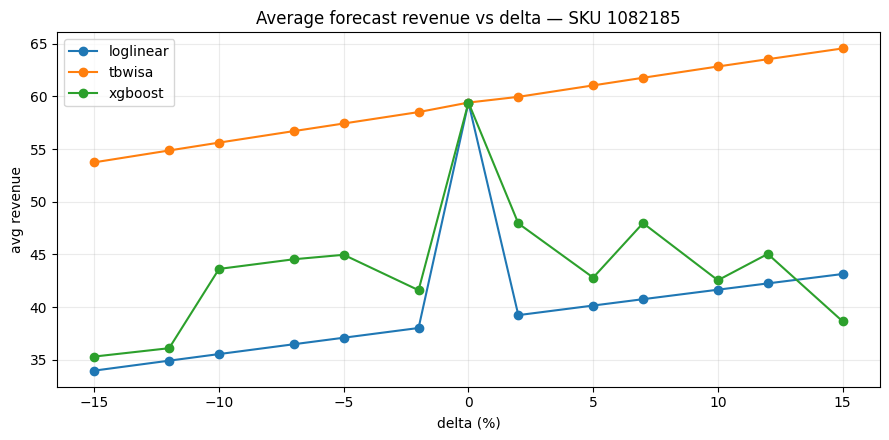

,model,delta_pct,start,end,len,avg,score
13,tbwisa,15,14,21,7,67.295985,67.295985
0,loglinear,0,22,30,8,62.559411,62.559411
26,xgboost,0,22,30,8,62.559411,62.559411


In [10]:
# Average forecast revenue vs delta
plt.figure(figsize=(9, 4.5))
for m in metrics['model'].unique():
    sub = metrics[metrics['model'] == m].sort_values('delta_pct')
    plt.plot(sub['delta_pct'], sub['avg_rev_forecast'], marker='o', label=m)
plt.title(f'Average forecast revenue vs delta — SKU {CASE_SKU}')
plt.xlabel('delta (%)')
plt.ylabel('avg revenue')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'average_forecast_revenue_vs_delta_case_sku_{CASE_SKU}.png', dpi=160, bbox_inches='tight')
plt.show()

best_per_model = windows.sort_values('score', ascending=False).groupby('model').head(1)
best_per_model

### 5.2 Case-study deep dive: show optimal window on cumulative revenue

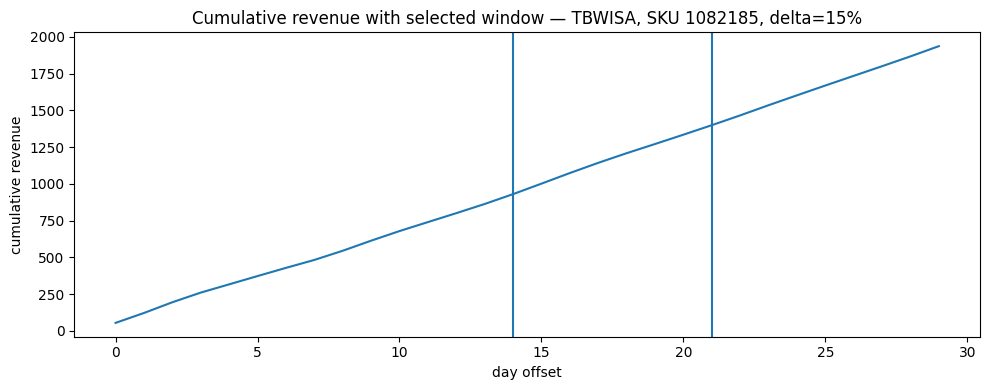

Best TBWISA delta: 15 %
Estimated uplift vs baseline (avg rev): 0.08644385462916199


In [11]:
# Choose best overall recommendation by uplift vs baseline using TBWISA
base_rev = metrics[(metrics['model']=='tbwisa') & (metrics['delta_pct']==0)]['avg_rev_forecast'].iloc[0]

best_tb = windows[windows['model']=='tbwisa'].sort_values('score', ascending=False).iloc[0]
best_pct = int(best_tb['delta_pct'])

p_hist, d_hist = scenarios['tbwisa'][best_pct]
pred = forecast_with(d_hist) * intent_w
rev = revenue(np.repeat(p_hist[-1], HORIZON), pred)

cum = np.cumsum(rev)
start = int(best_tb['start'])
end = int(best_tb['end'])

plt.figure(figsize=(10,4))
plt.plot(np.arange(HORIZON), cum)
plt.title(f'Cumulative revenue with selected window — TBWISA, SKU {CASE_SKU}, delta={best_pct}%')
plt.xlabel('day offset')
plt.ylabel('cumulative revenue')
plt.axvline(start)
plt.axvline(end)
plt.tight_layout()
plt.savefig(OUT_DIR / f'cumulative_revenue_with_selected_window_case_sku_{CASE_SKU}.png', dpi=160, bbox_inches='tight')
plt.show()

uplift = (np.mean(rev) - base_rev) / (base_rev + 1e-9)
print('Best TBWISA delta:', best_pct, '%')
print('Estimated uplift vs baseline (avg rev):', float(uplift))

### 5.3 Executive visualization: scenario curves and highlighted selected window

,delta_pct,mean_demand_horizon,mean_demand_window,mean_rev_window
0,-15,59.434138,61.969647,56.028715
1,-12,58.609473,61.114897,57.206116
2,-10,58.085706,60.572289,57.986808
3,-7,57.317543,59.774877,59.130882
4,-5,56.824406,59.258489,59.880703
5,-2,56.123841,58.522495,61.004465
6,0,55.850375,57.905255,61.592905
7,2,55.256053,57.617619,62.512691
8,5,54.649534,56.990457,63.650841
9,7,54.264054,56.590478,64.408006


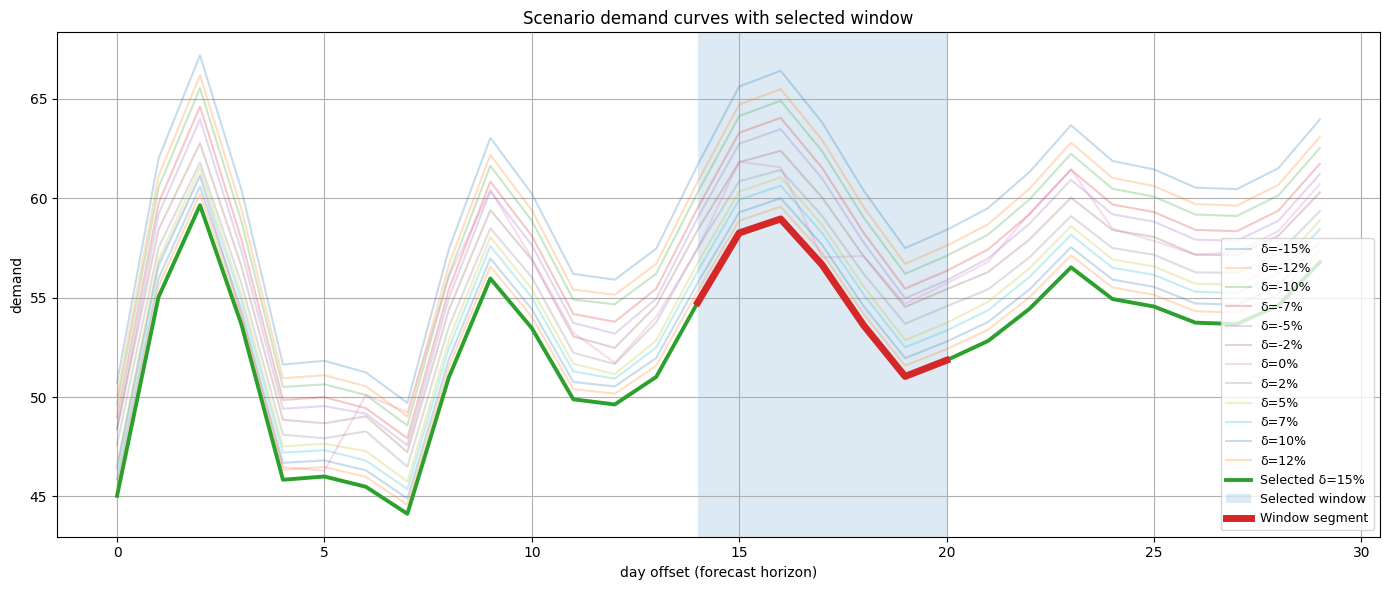

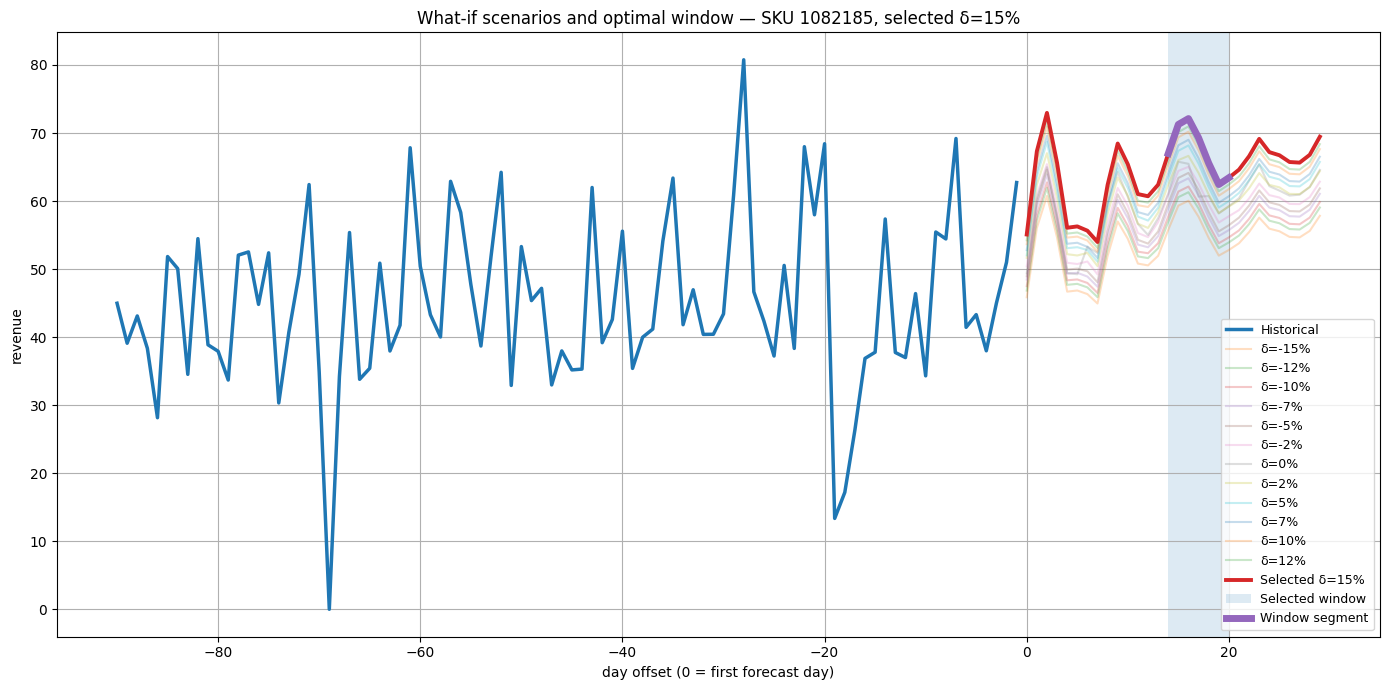

In [12]:
def _to_1d(x):
    return np.asarray(x, dtype=float).reshape(-1)

def plot_optimal_window_style(
    hist_rev=None,
    rev_by_delta=None,
    best_delta=None,
    start=None,
    end=None,
    title="TBWISA: Optimal window on forecasted revenue",
    alpha=0.25,
    save_path=None
):
    """Plot historical revenue and forecast revenue per scenario and highlight (start,end) on best_delta."""
    plt.figure(figsize=(14, 7))

    # Historical
    if hist_rev is not None:
        hist_rev = _to_1d(hist_rev)
        x_hist = np.arange(-len(hist_rev), 0)
        plt.plot(x_hist, hist_rev, label="Historical", linewidth=2.5)

    # Forecast horizon axis
    x = np.arange(HORIZON)

    # All scenarios
    for d, rev in rev_by_delta.items():
        if int(d) == int(best_delta):
            continue
        plt.plot(x, _to_1d(rev), alpha=alpha, label=f"δ={int(d)}%")

    # Best scenario emphasized
    best_rev = _to_1d(rev_by_delta[int(best_delta)])
    plt.plot(x, best_rev, linewidth=2.8, label=f"Selected δ={int(best_delta)}%")

    # Window highlight
    if start is not None and end is not None:
        plt.axvspan(start, end-1, alpha=0.15, label="Selected window")
        plt.plot(x[start:end], best_rev[start:end], linewidth=5, label="Window segment")

    plt.title(title)
    plt.xlabel("day offset (0 = first forecast day)")
    plt.ylabel("revenue")
    plt.grid(True)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

def plot_scenario_curves_with_window(
    scenarios_model: dict,
    windows_m: pd.DataFrame,
    best_delta: int,
    title: str = "Scenario revenue curves + selected window",
    show_all_deltas: bool = True,
    alpha: float = 0.25,
    hist_tail: int = 90,
    demand_save_path=None,
    revenue_save_path=None
):
    """Plot forecast-horizon revenue and demand for each delta and highlight the selected window on best_delta."""
    deltas_sorted = sorted([int(k) for k in scenarios_model.keys()])

    # Selected window for best_delta
    wrow = windows_m[windows_m['delta_pct'].astype(int) == int(best_delta)].sort_values('score', ascending=False).iloc[0]
    start = int(wrow['start']); end = int(wrow['end'])  # end is exclusive in our window table

    # Build trajectories per delta (forecast horizon only)
    rev_by_delta = {}
    dem_by_delta = {}
    for d in deltas_sorted:
        p_hist, d_hist = scenarios_model[int(d)]
        pred_demand = _to_1d(forecast_with(d_hist)) * _to_1d(intent_w)   # NPD timing embedded in intent_w
        price_f = np.repeat(_to_1d(p_hist)[-1], HORIZON)                 # keep consistent with your revenue evaluation
        rev_by_delta[int(d)] = price_f * pred_demand
        dem_by_delta[int(d)] = pred_demand

    # Historical revenue
    hist_rev = None
    if 'sku_df' in globals() and 'PRICE_COL' in globals() and 'DEMAND_COL' in globals():
        try:
            hist_rev = _to_1d(sku_df[PRICE_COL].values) * _to_1d(sku_df[DEMAND_COL].values)
            if hist_tail is not None and len(hist_rev) > hist_tail:
                hist_rev = hist_rev[-hist_tail:]
        except Exception:
            hist_rev = None
    # Demand summary (helps validate scenario direction before revenue)
    try:
        from IPython.display import display
        demand_summary = pd.DataFrame({
            'delta_pct': deltas_sorted,
            'mean_demand_horizon': [float(np.mean(dem_by_delta[int(d)])) for d in deltas_sorted],
            'mean_demand_window': [float(np.mean(dem_by_delta[int(d)][start:end])) for d in deltas_sorted],
            'mean_rev_window': [float(np.mean(rev_by_delta[int(d)][start:end])) for d in deltas_sorted],
        })
        display(demand_summary)
    except Exception:
        pass

    # Demand plot
    x = np.arange(HORIZON)
    plt.figure(figsize=(14, 6))
    if show_all_deltas:
        for d in deltas_sorted:
            if int(d) == int(best_delta):
                continue
            plt.plot(x, dem_by_delta[int(d)], alpha=alpha, label=f"δ={int(d)}%")

    plt.plot(x, dem_by_delta[int(best_delta)], linewidth=2.8, label=f"Selected δ={int(best_delta)}%")
    plt.axvspan(start, end-1, alpha=0.15, label="Selected window")
    plt.plot(x[start:end], dem_by_delta[int(best_delta)][start:end], linewidth=5, label="Window segment")

    plt.title("Scenario demand curves with selected window")
    plt.xlabel("day offset (forecast horizon)")
    plt.ylabel("demand")
    plt.grid(True)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    if demand_save_path is not None:
        plt.savefig(demand_save_path, dpi=160, bbox_inches='tight')
    plt.show()

    # Revenue plot (x_tbwisa-style)
    plot_optimal_window_style(
        hist_rev=hist_rev,
        rev_by_delta=rev_by_delta,
        best_delta=best_delta,
        start=start,
        end=end,
        title=title,
        alpha=alpha,
        save_path=revenue_save_path
    )


# Use TBWISA recommended delta/window
try:
    best_delta_exec = int(decision_table_screened.loc[decision_table_screened['model']=='tbwisa','recommended_delta_pct'].iloc[0])
except Exception:
    best_delta_exec = int(windows[windows['model']=='tbwisa'].sort_values('score', ascending=False).iloc[0]['delta_pct'])

plot_scenario_curves_with_window(
    scenarios['tbwisa'],
    windows[windows['model']=='tbwisa'],
    best_delta=best_delta_exec,
    title=f"What-if scenarios and optimal window — SKU {CASE_SKU}, selected δ={best_delta_exec}%",
    demand_save_path=OUT_DIR / f'scenario_demand_curves_with_selected_window_case_sku_{CASE_SKU}.png',
    revenue_save_path=OUT_DIR / f'what_if_scenarios_and_optimal_window_case_sku_{CASE_SKU}.png'
)

## 6) Executive decision table (delta, window and uplift)

In [13]:
decision_rows = []
for m in windows['model'].unique():
    base_m = metrics[(metrics['model']==m) & (metrics['delta_pct']==0)]['avg_rev_forecast'].iloc[0]
    wbest = windows[windows['model']==m].sort_values('score', ascending=False).iloc[0]
    mbest = metrics[(metrics['model']==m) & (metrics['delta_pct']==int(wbest['delta_pct']))].iloc[0]
    uplift = (mbest['avg_rev_forecast'] - base_m) / (base_m + 1e-9)

    decision_rows.append({
        'model': m,
        'forecast_backend': backend,
        'recommended_delta_pct': int(wbest['delta_pct']),
        'window_start_offset_days': int(wbest['start']),
        'window_length_days': int(wbest['len']),
        'avg_rev_forecast': float(mbest['avg_rev_forecast']),
        'baseline_avg_rev': float(base_m),
        'uplift_ratio': float(uplift),
        'window_score': float(wbest['score'])
    })

decision_table = pd.DataFrame(decision_rows).sort_values('uplift_ratio', ascending=False).reset_index(drop=True)
decision_table

,model,forecast_backend,recommended_delta_pct,window_start_offset_days,window_length_days,avg_rev_forecast,baseline_avg_rev,uplift_ratio,window_score
0,tbwisa,scenario_gen_transformer_global,15,14,7,64.542547,59.407163,0.086444,67.295985
1,loglinear,scenario_gen_transformer_global,0,22,8,59.407163,59.407163,0.000000,62.559411
2,xgboost,scenario_gen_transformer_global,0,22,8,59.407163,59.407163,0.000000,62.559411


## 7) Explainability screening (X-TBWISA) using SHAP

This section implements the screening / flagging layer used for auditability:

- SHAP drift across adjacent deltas (stability)
- Economic checks (alignment, monotonicity, plausibility)
- Produces a per-delta status: *Accept / Accept_Caution / Flag*

Note: screening is a consistency / robustness check does not claim SHAP is causal.


Surrogate fidelity MAE: 0.31612182150081714 RMSE: 0.5404724220675866


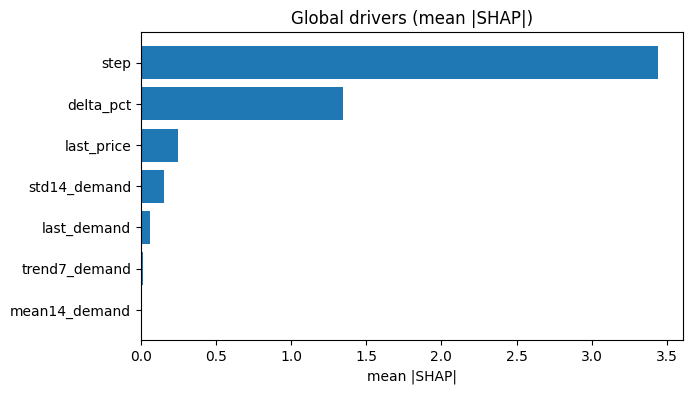

Delta alignment rate: 0.9205128205128205


,feature,mean_abs_shap
1,step,3.438246
0,delta_pct,1.342756
2,last_price,0.244644
5,std14_demand,0.152791
3,last_demand,0.059319
6,trend7_demand,0.013200
4,mean14_demand,0.000000


In [14]:
# Teacher: TBWISA scenario -> forecasted demand (intention-weighted)
def build_surrogate_dataset(tb_scenarios):
    rows=[]
    for pct, (p_hist, d_hist) in tb_scenarios.items():
        teacher = forecast_with(d_hist) * intent_w
        last_price = float(p_hist[-1])
        last_demand = float(d_hist[-1])
        mean14 = float(np.mean(d_hist[-14:])) if len(d_hist) >= 14 else float(np.mean(d_hist))
        std14 = float(np.std(d_hist[-14:])) if len(d_hist) >= 14 else float(np.std(d_hist))
        trend7 = float(d_hist[-1] - d_hist[-7]) if len(d_hist) >= 7 else 0.0

        for t in range(HORIZON):
            rows.append({
                'delta_pct': int(pct),
                'step': int(t+1),
                'last_price': last_price,
                'last_demand': last_demand,
                'mean14_demand': mean14,
                'std14_demand': std14,
                'trend7_demand': trend7,
                'teacher_demand_t': float(teacher[t])
            })
    return pd.DataFrame(rows)

sur_df = build_surrogate_dataset(scenarios['tbwisa'])
FEATURES = [c for c in sur_df.columns if c != 'teacher_demand_t']
X = sur_df[FEATURES].values
y = sur_df['teacher_demand_t'].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED)
surrogate = xgbregressor.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=SEED, n_jobs=4
)
surrogate.fit(Xtr, ytr)
pred = surrogate.predict(Xte)
mae = mean_absolute_error(yte, pred)
rmse = float(np.sqrt(mean_squared_error(yte, pred)))
print('Surrogate fidelity MAE:', float(mae), 'RMSE:', float(rmse))

explainer = shap.TreeExplainer(surrogate)
X_sample = sur_df[FEATURES]
shap_vals = explainer.shap_values(X_sample)

abs_mean = np.mean(np.abs(shap_vals), axis=0)
imp = pd.DataFrame({'feature': FEATURES, 'mean_abs_shap': abs_mean}).sort_values('mean_abs_shap', ascending=False)

# Plot global importance (top 12)
topk = imp.head(12).sort_values('mean_abs_shap')
plt.figure(figsize=(7,4))
plt.barh(topk['feature'], topk['mean_abs_shap'])
plt.title('Global drivers (mean |SHAP|)')
plt.xlabel('mean |SHAP|')
plt.show()

# Delta alignment check: expect shap(delta_pct)*delta_pct < 0 (price up -> demand down)
delta_idx = FEATURES.index('delta_pct')
aligned = (shap_vals[:, delta_idx].astype(float) * X_sample['delta_pct'].values.astype(float)) < 0
alignment_rate = float(np.mean(aligned))
print('Delta alignment rate:', alignment_rate)

imp.head(15)

### 7.1 Accept / Flag decision rule

Decision logic (high level):
- *Accept*: stable explanations + passes economic checks
- *Accept_Caution*: usable but with warnings (e.g., plausibility or reliability gate)
- *Flag*: unstable or inconsistent behavior → avoid full rollout

The executive policy later converts these statuses into *EXECUTE / PILOT / HOLD* actions.


In [15]:
# X-TBWISA screening: delta semantics, aligned-window drift and tolerant econ checks
# Key upgrades vs the initial implementation:
# 1) Determine delta semantics from the PRICE transform used in scenario evaluation, not from demand trend.
# 2) Compute SHAP drift on a single reference window (the recommended execution window) to avoid false drift due to window mismatch.
# 3) Use an adaptive plausibility threshold (percentile-based) instead of a hard corr<0 rule (confounding-safe).
# 4) Add small tolerances so noise doesn't cause blanket FLAGs.

EPS = 1e-8

# Quantile used for drift thresholds and (by default) for plausibility thresholding
DRIFT_Q = 0.75

# Relative tolerance for outcome monotonicity (2% by default)
MONO_TOL_REL = 0.02

# Small tolerance for SHAP sign alignment (allows tiny violations)
ALIGN_TOL = 0.0

PRICE_FEATURES = ['delta_pct', 'last_price']  # {delta, P_t^delta} proxy

def _safe_corr(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if len(x) < 3 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def infer_delta_semantics_from_transform():
    """Infer delta semantics from the price transform used in scenario evaluation.

    It does not infer semantics from demand response, because that can be confounded
    (e.g., promotions). Instead, it is read the transform definition:
      - if apply_price_delta(p, +x) > p -> +delta means price increase
      - else -> +delta means discount (price decrease)
    """
    # If the scenario cell defined DELTA_SEMANTICS, trust it (single source of truth).
    try:
        s = str(DELTA_SEMANTICS).strip().lower()
        if s in ['price_increase', 'increase', 'up']:
            return 'price_increase'
        if s in ['discount', 'price_decrease', 'decrease', 'down']:
            return 'discount'
    except Exception:
        pass

    # Otherwise, probe apply_price_delta if available.
    try:
        p = np.asarray([100.0], float)
        p_pos = float(apply_price_delta(p, 10.0)[0])
        return 'price_increase' if p_pos > float(p[0]) else 'discount'
    except Exception:
        # Safe default: match current notebook price transform convention.
        return 'price_increase'

def compute_window_phi(sur_df, shap_vals, windows_m, features, ref_window=None, use_ref_for_all=True):
    """Return phi(delta) vectors and both the per-delta best windows + the reference window.

    - win_map: per-delta best (start,len) from windows_m.
    - ref_window: (start,len) used to aggregate phi for drift comparisons.
    """
    # Map delta -> (start, len) from the model's window table
    win_map = {int(r.delta_pct): (int(r.start), int(r.len)) for r in windows_m.itertuples(index=False)}

    # Pick reference window: by default, use the highest-scoring window (executive window)
    if ref_window is None:
        if 'score' in windows_m.columns and len(windows_m):
            best = windows_m.sort_values('score', ascending=False).iloc[0]
            ref_window = (int(best['start']), int(best['len']))
        else:
            # fallback: mode window (start,len)
            starts = [v[0] for v in win_map.values()]
            lens = [v[1] for v in win_map.values()]
            ref_window = (int(pd.Series(starts).mode().iloc[0]), int(pd.Series(lens).mode().iloc[0]))

    ref_start, ref_L = ref_window

    phi = {}
    for delta in sorted(win_map.keys()):
        if use_ref_for_all:
            start, L = ref_start, ref_L
        else:
            start, L = win_map[int(delta)]

        # sur_df.step is 1..HORIZON; windows.start is 0-based offset
        mask = (sur_df['delta_pct'].astype(int) == int(delta)) & (sur_df['step'] > start) & (sur_df['step'] <= start + L)
        if mask.sum() == 0:
            # fallback: use all steps for that delta
            mask = (sur_df['delta_pct'].astype(int) == int(delta))
        phi[int(delta)] = np.mean(shap_vals[mask.values, :], axis=0).astype(float)

    return phi, win_map, ref_window

def shap_drift(phi_map, deltas_sorted, eps=EPS):
    pairs=[]
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        va, vb = phi_map[int(a)], phi_map[int(b)]
        d = float(np.sum(np.abs(vb - va)) / (np.sum(np.abs(va)) + eps))
        pairs.append({'delta_a': int(a), 'delta_b': int(b), 'dshap': d})
    return pd.DataFrame(pairs)

def price_drift_ratio(phi_map, deltas_sorted, features, price_features=PRICE_FEATURES, eps=EPS):
    price_idx = [features.index(f) for f in price_features if f in features]
    pairs=[]
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        va, vb = phi_map[int(a)], phi_map[int(b)]
        diff = np.abs(vb - va)
        denom = float(np.sum(diff) + eps)
        numer = float(np.sum(diff[price_idx])) if price_idx else 0.0
        pairs.append({'delta_a': int(a), 'delta_b': int(b), 'r_price': float(numer / denom)})
    return pd.DataFrame(pairs)

def monotonicity_local_ok(tb_scenarios, deltas_sorted, semantics, tail=30, tol_rel=MONO_TOL_REL):
    # Use mean demand over last `tail` points of counterfactual series
    mean_tail = {}
    for d in deltas_sorted:
        _, d_hist = tb_scenarios[int(d)]
        d_hist = np.asarray(d_hist, float)
        mean_tail[int(d)] = float(np.mean(d_hist[-tail:])) if len(d_hist) else np.nan

    pair_ok = {}
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        ya = mean_tail[int(a)]; yb = mean_tail[int(b)]
        if np.isnan(ya) or np.isnan(yb):
            pair_ok[(int(a), int(b))] = True
            continue

        # Expected direction:
        # - price_increase: higher delta => lower demand
        # - discount      : higher delta => higher demand
        if semantics == 'price_increase':
            pair_ok[(int(a), int(b))] = bool(yb <= ya * (1.0 + tol_rel))
        else:  # discount
            pair_ok[(int(a), int(b))] = bool(yb >= ya * (1.0 - tol_rel))

    # Local OK for each delta based on its neighbors
    local_ok = {}
    for i, d in enumerate(deltas_sorted):
        ok_prev = True
        ok_next = True
        if i > 0:
            ok_prev = pair_ok[(int(deltas_sorted[i-1]), int(d))]
        if i < len(deltas_sorted) - 1:
            ok_next = pair_ok[(int(d), int(deltas_sorted[i+1]))]
        local_ok[int(d)] = bool(ok_prev and ok_next)

    return local_ok, mean_tail

def alignment_ok(phi_map, deltas_sorted, features, semantics, delta_feature='delta_pct', tol=ALIGN_TOL):
    """SHAP sign alignment check for the delta feature (Eq. 10), adapted for delta semantics."""
    if delta_feature not in features:
        return {int(d): True for d in deltas_sorted}
    j = features.index(delta_feature)
    out={}
    for d in deltas_sorted:
        d = int(d)
        if d == 0:
            out[d] = True
            continue

        s = float(d) * float(phi_map[d][j])
        if semantics == 'price_increase':
            # expected negative effect for +delta (higher price => lower demand)
            out[d] = bool(s <= tol)
        else:
            # discount: +delta => lower price => higher demand (positive effect)
            out[d] = bool(s >= -tol)
    return out

def plausibility_ok(tb_scenarios, deltas_sorted, corr_q=DRIFT_Q):
    """Economic plausibility based on price-demand correlation, but robust to confounding.

    Instead of a hard corr<0 rule, the approach is:
      - compute corr per delta
      - compute an adaptive threshold tau_corr = Q(corr_q)
      - treat scenarios with corr <= tau_corr as plausible
    This flags only unusually positive correlations as suspicious, while avoiding blanket failures.
    """
    corr_map={}
    for d in deltas_sorted:
        p_hist, d_hist = tb_scenarios[int(d)]
        corr_map[int(d)] = _safe_corr(p_hist, d_hist)

    vals = np.asarray([v for v in corr_map.values() if v is not None and not np.isnan(v)], float)
    tau_corr = float(np.quantile(vals, corr_q)) if len(vals) else np.nan

    out={}
    for d in deltas_sorted:
        c = corr_map[int(d)]
        if c is None or np.isnan(c) or np.isnan(tau_corr):
            out[int(d)] = True
        else:
            out[int(d)] = bool(float(c) <= tau_corr)
    return out, corr_map, tau_corr

def assign_drift_to_delta(drift_df, ratio_df, deltas_sorted):
    # Build per-delta drift statistics using max drift to neighbors
    drift_prev = {int(d): np.nan for d in deltas_sorted}
    drift_next = {int(d): np.nan for d in deltas_sorted}
    r_prev = {int(d): np.nan for d in deltas_sorted}
    r_next = {int(d): np.nan for d in deltas_sorted}

    for r in drift_df.itertuples(index=False):
        a, b, dsh = int(r.delta_a), int(r.delta_b), float(r.dshap)
        drift_next[a] = dsh
        drift_prev[b] = dsh

    for r in ratio_df.itertuples(index=False):
        a, b, rp = int(r.delta_a), int(r.delta_b), float(r.r_price)
        r_next[a] = rp
        r_prev[b] = rp

    max_drift = {}
    max_rprice = {}
    max_pair = {}
    for d in deltas_sorted:
        d = int(d)
        candidates = []
        if not np.isnan(drift_prev[d]):
            candidates.append(('prev', drift_prev[d], r_prev[d]))
        if not np.isnan(drift_next[d]):
            candidates.append(('next', drift_next[d], r_next[d]))
        if len(candidates) == 0:
            max_drift[d], max_rprice[d], max_pair[d] = np.nan, np.nan, None
        else:
            side, md, mrp = sorted(candidates, key=lambda x: x[1], reverse=True)[0]
            max_drift[d], max_rprice[d], max_pair[d] = float(md), float(mrp), side
    return drift_prev, drift_next, max_drift, max_rprice, max_pair

def x_tbwisa_flagging(tb_scenarios, sur_df, shap_vals, windows_m, features,
                      drift_q=DRIFT_Q, eps=EPS, price_features=PRICE_FEATURES,
                      econ_mode='standard', min_accepted=1,
                      delta_semantics='auto', mono_tol_rel=MONO_TOL_REL,
                      use_ref_window_for_drift=True):
    deltas_sorted = sorted([int(d) for d in tb_scenarios.keys()])

    semantics = infer_delta_semantics_from_transform() if delta_semantics == 'auto' else str(delta_semantics)

    # Compute phi (delta) on a single reference window to avoid window-mismatch drift
    phi_map, win_map, ref_window = compute_window_phi(
        sur_df, shap_vals, windows_m, features,
        ref_window=None,
        use_ref_for_all=bool(use_ref_window_for_drift)
    )

    drift_df = shap_drift(phi_map, deltas_sorted, eps=eps)
    ratio_df = price_drift_ratio(phi_map, deltas_sorted, features, price_features=price_features, eps=eps)

    tau_drift = float(np.quantile(drift_df['dshap'].values, drift_q)) if len(drift_df) else np.nan
    tau_price = float(np.quantile(ratio_df['r_price'].values, drift_q)) if len(ratio_df) else np.nan

    # Econ checks with semantics and adaptive plausibility
    align = alignment_ok(phi_map, deltas_sorted, features, semantics, delta_feature='delta_pct')
    plaus, corr_map, tau_corr = plausibility_ok(tb_scenarios, deltas_sorted, corr_q=drift_q)
    mono_local, mean_tail = monotonicity_local_ok(tb_scenarios, deltas_sorted, semantics, tol_rel=mono_tol_rel)

    drift_prev, drift_next, max_drift, max_rprice, max_pair = assign_drift_to_delta(drift_df, ratio_df, deltas_sorted)

    rows=[]
    for d in deltas_sorted:
        drift_flag = (not np.isnan(max_drift[d])) and (not np.isnan(tau_drift)) and (max_drift[d] > tau_drift)

        # Economic screening
        # Treats plausibility as a hard warning, which drives Accept_Caution,
        # while monotonicity/alignment are soft warnings by default for audit-only,
        # because retail demand can be confounded and noisy.
        hard_econ = []
        soft_econ = []
        if not plaus[d]:
            hard_econ.append('economic_plausibility_fail')
        if not mono_local[d]:
            soft_econ.append('monotonicity_fail')
        if not align[d]:
            soft_econ.append('alignment_fail')

        econ_reasons = hard_econ + soft_econ


        drift_reasons = soft_econ
        if drift_flag:
            # reason label: price-dominated vs general drift
            if (not np.isnan(max_rprice[d])) and (not np.isnan(tau_price)) and (max_rprice[d] > tau_price):
                drift_reasons.append('high_shap_drift_price_dominated')
            else:
                drift_reasons.append('high_shap_drift')

        # Status assignment
        # Modes:
        #   * strict  : any econ failure => Flag (paper-tight screening)
        #   * standard: econ failures => Accept_Caution if drift is stable
        #   * loose   : same as standard and always allow baseline (delta=0) when drift is stable
        strict_econ = (econ_mode == 'strict')
        baseline_always_ok = (econ_mode == 'loose')

        if drift_flag:
            status = 'Flag'
            reasons = drift_reasons + econ_reasons  # keep full audit trail
        else:
            if len(hard_econ) == 0:
                status = 'Accept'
                reasons = soft_econ
            else:
                if baseline_always_ok and int(d) == 0:
                    status = 'Accept'
                    reasons = econ_reasons  # still report warnings for audit
                elif strict_econ:
                    status = 'Flag'
                    reasons = econ_reasons
                else:
                    status = 'Accept_Caution'
                    reasons = econ_reasons

        start, L = win_map[int(d)]
        rows.append({
            'delta_pct': int(d),
            'window_start_offset_days': int(start),
            'window_length_days': int(L),
            'status': status,
            'reason': ','.join(reasons) if reasons else 'ok',
            'delta_semantics': semantics,
            'ref_window_start': int(ref_window[0]),
            'ref_window_length': int(ref_window[1]),
            'corr_price_demand_hist': float(corr_map[int(d)]) if corr_map[int(d)] is not None else np.nan,
            'tau_corr': float(tau_corr) if not np.isnan(tau_corr) else np.nan,
            'mean_demand_tail': float(mean_tail[int(d)]),
            'aligned': bool(align[d]),
            'monotone_local': bool(mono_local[d]),
            'plausible': bool(plaus[d]),
            'dshap_prev': float(drift_prev[int(d)]) if not np.isnan(drift_prev[int(d)]) else np.nan,
            'dshap_next': float(drift_next[int(d)]) if not np.isnan(drift_next[int(d)]) else np.nan,
            'dshap_max': float(max_drift[int(d)]) if not np.isnan(max_drift[int(d)]) else np.nan,
            'r_price_max': float(max_rprice[int(d)]) if not np.isnan(max_rprice[int(d)]) else np.nan,
        })

    screening_df = pd.DataFrame(rows).sort_values('delta_pct').reset_index(drop=True)

    # Adaptive guardrail: ensure at least min_accepted deltas are actionable
    non_flag = screening_df[~screening_df['status'].astype(str).str.lower().eq('flag')]
    if len(non_flag) < int(min_accepted):
        tmp = screening_df.copy()
        tmp['abs_delta'] = tmp['delta_pct'].abs()
        tmp['dshap_rank'] = tmp['dshap_max'].fillna(0.0)
        tmp = tmp.sort_values(['dshap_rank', 'abs_delta'], ascending=[True, True])
        promote = tmp.head(int(min_accepted)).index.tolist()
        for idx in promote:
            if str(screening_df.loc[idx, 'status']).lower() == 'flag':
                screening_df.loc[idx, 'status'] = 'Accept_Caution'
                r = str(screening_df.loc[idx, 'reason'])
                if r and r != 'ok':
                    screening_df.loc[idx, 'reason'] = r + ',relaxed_accept'
                else:
                    screening_df.loc[idx, 'reason'] = 'relaxed_accept'
        screening_df = screening_df.sort_values('delta_pct').reset_index(drop=True)

    return screening_df, drift_df, ratio_df, tau_drift, tau_price


# Run screening for TBWISA (X-TBWISA layer)
model_for_x = 'tbwisa'
screening_df, drift_pairs, ratio_pairs, tau_drift, tau_price = x_tbwisa_flagging(
    scenarios[model_for_x], sur_df, shap_vals, windows[windows['model']==model_for_x], FEATURES,
    econ_mode='loose',              # 'strict' / 'standard' / 'loose'
    min_accepted=1,
    delta_semantics='auto',         # 'auto' / 'price_increase' / 'discount'
    mono_tol_rel=0.02,
    use_ref_window_for_drift=True   # drift comparisons use the executive reference window
)

print('tau_drift:', tau_drift, 'tau_price:', tau_price)
print('Inferred delta semantics:', screening_df["delta_semantics"].iloc[0])
print('Reference window for drift:', (int(screening_df["ref_window_start"].iloc[0]), int(screening_df["ref_window_length"].iloc[0])))
display(screening_df)

# Attach screening outcome to the executive decision table
decision_table_screened = decision_table.copy()
tb_row = decision_table_screened['model'] == model_for_x
decision_table_screened.loc[tb_row, 'x_tbwisa_status'] = decision_table_screened.loc[tb_row, 'recommended_delta_pct'].map(
    dict(zip(screening_df['delta_pct'], screening_df['status']))
)
decision_table_screened.loc[tb_row, 'x_tbwisa_reason'] = decision_table_screened.loc[tb_row, 'recommended_delta_pct'].map(
    dict(zip(screening_df['delta_pct'], screening_df['reason']))
)
display(decision_table_screened)

tau_drift: 0.20982613687449989 tau_price: 0.8701762781317995
Inferred delta semantics: price_increase
Reference window for drift: (14, 7)


,delta_pct,window_start_offset_days,window_length_days,status,reason,delta_semantics,ref_window_start,ref_window_length,corr_price_demand_hist,tau_corr,mean_demand_tail,aligned,monotone_local,plausible,dshap_prev,dshap_next,dshap_max,r_price_max
0,-15,14,7,Accept,ok,price_increase,14,7,-0.161247,-0.159864,54.072824,True,True,True,NaN,0.130646,0.130646,0.831208
1,-12,14,7,Accept,ok,price_increase,14,7,-0.160748,-0.159864,53.308690,True,True,True,0.130646,0.084977,0.130646,0.831208
2,-10,14,7,Accept,ok,price_increase,14,7,-0.160344,-0.159864,52.824375,True,True,True,0.084977,0.150212,0.150212,0.841835
3,-7,14,7,Accept,ok,price_increase,14,7,-0.159864,-0.159864,52.081861,True,True,True,0.150212,0.169066,0.169066,0.855160
4,-5,14,7,Flag,high_shap_drift_price_dominated,price_increase,14,7,-0.159967,-0.159864,51.653976,True,True,True,0.169066,0.217366,0.217366,0.873536
5,-2,14,7,Flag,"high_shap_drift,economic_plausibility_fail",price_increase,14,7,-0.159647,-0.159864,51.174845,True,True,False,0.217366,0.486528,0.486528,0.352666
6,0,22,8,Flag,high_shap_drift,price_increase,14,7,-0.175934,-0.159864,51.433333,True,True,True,0.486528,0.441664,0.486528,0.352666
7,2,14,7,Flag,"high_shap_drift,economic_plausibility_fail",price_increase,14,7,-0.159647,-0.159864,50.383579,True,True,False,0.441664,0.207313,0.441664,0.270820
8,5,14,7,Accept,ok,price_increase,14,7,-0.159967,-0.159864,49.676995,True,True,True,0.207313,0.104161,0.207313,0.898954
9,7,14,7,Accept,ok,price_increase,14,7,-0.159864,-0.159864,49.307294,True,True,True,0.104161,0.161378,0.161378,0.720892


,model,forecast_backend,recommended_delta_pct,window_start_offset_days,window_length_days,avg_rev_forecast,baseline_avg_rev,uplift_ratio,window_score,x_tbwisa_status,x_tbwisa_reason
0,tbwisa,scenario_gen_transformer_global,15,14,7,64.542547,59.407163,0.086444,67.295985,Accept,ok
1,loglinear,scenario_gen_transformer_global,0,22,8,59.407163,59.407163,0.000000,62.559411,NaN,NaN
2,xgboost,scenario_gen_transformer_global,0,22,8,59.407163,59.407163,0.000000,62.559411,NaN,NaN


## 8) Export executive artifacts

Exports the following files into `OUT_DIR`:
- decision tables (raw + screened)
- per-delta metrics
- optimal windows
- global SHAP importance
- executive JSON summary (single object suitable for a dashboard)

These artifacts are designed to be committed to experiment logs or attached to reports.


In [16]:
# Save key tables
metrics.to_csv(OUT_DIR / f'metrics_case_sku_{CASE_SKU}.csv', index=False)
windows.to_csv(OUT_DIR / f'windows_case_sku_{CASE_SKU}.csv', index=False)
decision_table.to_csv(OUT_DIR / f'decision_table_case_sku_{CASE_SKU}.csv', index=False)
imp.to_csv(OUT_DIR / f'shap_global_importance_case_sku_{CASE_SKU}.csv', index=False)

# Save screened decision table
try:
    decision_table_screened.to_csv(OUT_DIR / f'decision_table_screened_case_sku_{CASE_SKU}.csv', index=False)
except Exception:
    pass

# Executive best row
try:
    best = decision_table_screened.iloc[0].to_dict()
except Exception:
    best = decision_table.iloc[0].to_dict()

# Attach X-TBWISA screening artifacts
x_tbwisa_payload = None
try:
    _d = int(best.get('recommended_delta_pct', 0))
    _row = screening_df[screening_df['delta_pct'] == _d].iloc[0].to_dict()
    x_tbwisa_payload = {
        'screening_model': str(model_for_x),
        'tau_drift': float(tau_drift),
        'tau_price': float(tau_price),
        'recommended_delta_pct': int(_d),
        'status': str(_row.get('status')),
        'reason': str(_row.get('reason')),
        'dshap_max': float(_row.get('dshap_max')) if _row.get('dshap_max') is not None else None,
        'r_price_max': float(_row.get('r_price_max')) if _row.get('r_price_max') is not None else None,
        'aligned': bool(_row.get('aligned')),
        'plausible': bool(_row.get('plausible')),
        'monotone_local': bool(_row.get('monotone_local')),
    }
except Exception:
    x_tbwisa_payload = None

# Actionable outcome policy
def _nearest_accepted_delta(screening_df, target_delta):
    """Pick nearest delta that is actionable: Accept or Accept_Caution.
    Preference: same sign as target, then smallest distance."""
    try:
        target_delta = int(target_delta)
    except Exception:
        return None
    if screening_df is None or len(screening_df) == 0:
        return None

    acc = screening_df[screening_df['status'].astype(str).str.lower().isin(['accept', 'accept_caution', 'accept-with-caution'])]
    if len(acc) == 0:
        return None

    acc_d = acc['delta_pct'].astype(int).tolist()

    if target_delta != 0:
        same_sign = [d for d in acc_d if (d == 0) or (d > 0 and target_delta > 0) or (d < 0 and target_delta < 0)]
        if len(same_sign) > 0:
            acc_d = same_sign

    acc_d = sorted(acc_d, key=lambda d: (abs(d - target_delta), abs(d)))
    return int(acc_d[0]) if len(acc_d) else None

def _econ_score_gap_fallback_delta(screening_df, windows_df, model_name, target_delta, best_score, score_gap=0.07):
    """If economic plausibility fails, optionally fall back to the nearest ACCEPT delta whose score is within (1-score_gap) of best_score."""
    try:
        best_score = float(best_score)
        target_delta = int(target_delta)
    except Exception:
        return None

    if screening_df is None or windows_df is None or len(screening_df)==0 or len(windows_df)==0:
        return None

    acc = screening_df[screening_df['status'].astype(str).str.lower().eq('accept')].copy()
    if len(acc)==0:
        return None

    # Attach window scores for the same model
    w = windows_df[windows_df['model'].astype(str).str.lower().eq(str(model_name).lower())][['delta_pct','score','start','len']].copy()
    if len(w)==0:
        return None
    w['delta_pct'] = w['delta_pct'].astype(int)
    acc['delta_pct'] = acc['delta_pct'].astype(int)

    acc = acc.merge(w, on='delta_pct', how='left')
    acc = acc.dropna(subset=['score'])
    if len(acc)==0:
        return None

    thresh = best_score * (1.0 - float(score_gap))
    acc = acc[acc['score'].astype(float) >= thresh]
    if len(acc)==0:
        return None

    # Nearest accept delta to the target
    acc = acc.sort_values(['delta_pct'])
    acc['dist'] = (acc['delta_pct'] - target_delta).abs()
    acc = acc.sort_values(['dist', 'delta_pct'])
    return int(acc.iloc[0]['delta_pct'])


def _npd_alpha_from_globals():
    try:
        return float(NPD_ALPHA)
    except Exception:
        return 0.0

def _intent_norm_from_globals(horizon):
    # intent_norm may exist, else reconstruct from intent.
    try:
        arr = np.asarray(intent_norm, float)[:horizon]
        if arr.size:
            return arr
    except Exception:
        pass
    try:
        arr = np.asarray(intent.values, float)[:horizon]
        m = float(np.max(arr)) if arr.size else 0.0
        return (arr / m) if m > 0 else np.ones(horizon, float)
    except Exception:
        return None

def adjust_start_by_intent(start, L, intent_norm_arr, alpha, max_shift=7):
    """Shift window start toward higher intention only when alpha>0 and within max_shift days."""
    try:
        start = int(start); L = int(L)
    except Exception:
        return start, 0, None
    if alpha <= 0 or intent_norm_arr is None:
        return start, 0, None
    x = np.asarray(intent_norm_arr, float)
    if L <= 0 or len(x) < L:
        return start, 0, None

    roll = np.convolve(x, np.ones(L, float) / float(L), mode='valid')  # length H-L+1
    lo = max(0, start - int(max_shift))
    hi = min(len(roll) - 1, start + int(max_shift))
    if lo > hi:
        return start, 0, None
    s_int = lo + int(np.argmax(roll[lo:hi+1]))
    shift = int(s_int - start)
    return int(s_int), shift, float(roll[s_int])


# Config: if recommendation is Accept_Caution due to economic_plausibility_fail, fall back to nearest ACCEPT delta
ECON_FALLBACK_SCORE_GAP = 0.07  # 7% default; set to 0.03 for stricter, 0.10 for looser

# Elasticity reliability gate (decision safety): downgrade EXECUTE -> PILOT when elasticity is unstable
ELAST_R2_MIN = 0.20              # if r2 below this, treat elasticity as unreliable
ELAST_ABS_MAX_FOR_EXEC = 4.0     # if |elasticity| exceeds this, downgrade
UPLIFT_RATIO_MAX_FOR_EXEC = 0.50 # if predicted uplift exceeds this, downgrade
ELAST_RELIABILITY_GATE_ENABLED = True

def build_actionable_outcome(best_row, x_payload=None, screening_df=None, metrics_df=None, windows_df=None):
    d = int(best_row.get('recommended_delta_pct', 0))
    L = int(best_row.get('window_length_days', 0))
    start = int(best_row.get('window_start_offset_days', 0))

    status = None
    reason = None
    if best_row.get('x_tbwisa_status') is not None and str(best_row.get('x_tbwisa_status')) != 'nan':
        status = str(best_row.get('x_tbwisa_status'))
    if best_row.get('x_tbwisa_reason') is not None and str(best_row.get('x_tbwisa_reason')) != 'nan':
        reason = str(best_row.get('x_tbwisa_reason'))

    if status is None and x_payload is not None:
        status = str(x_payload.get('status'))
    if reason is None and x_payload is not None:
        reason = str(x_payload.get('reason'))

    status_norm = (status or 'Unscreened').strip()
    status_l = (status_norm or '').strip().lower()
    reason_norm = (reason or 'not_available').strip()
    tokens = [t.strip() for t in reason_norm.split(',') if t.strip()] if reason_norm else []
    tokens_set = set(tokens)

    # Elasticity reliability gate (TBWISA)
    elast_beta = None
    elast_r2 = None
    elast_gate = False
    elast_gate_reasons = []
    elast_event_used = None
    elast_n_fit_event = None
    try:
        if ELAST_RELIABILITY_GATE_ENABLED and str(best_row.get('model', '')).lower() == 'tbwisa':
            _meta = None
            try:
                _meta = getattr(tbwisa, '_last_elasticity_meta', None)
            except Exception:
                _meta = None
            if isinstance(_meta, dict):
                elast_beta = float(_meta.get('beta_final', _meta.get('beta_raw', np.nan)))
                elast_r2 = float(_meta.get('r2', np.nan))
                elast_event_used = _meta.get('event_used', None)
                elast_n_fit_event = _meta.get('n_fit_event', None)

            uplift_ratio = float(best_row.get('uplift_ratio', 0.0) or 0.0)

            if elast_r2 is not None and (not math.isnan(elast_r2)) and (elast_r2 < float(ELAST_R2_MIN)):
                elast_gate = True
                elast_gate_reasons.append('low_elasticity_r2')
            if elast_beta is not None and (not math.isnan(elast_beta)) and (abs(float(elast_beta)) > float(ELAST_ABS_MAX_FOR_EXEC)):
                elast_gate = True
                elast_gate_reasons.append('high_elasticity_magnitude')
            if uplift_ratio is not None and (not math.isnan(float(uplift_ratio))) and (float(uplift_ratio) > float(UPLIFT_RATIO_MAX_FOR_EXEC)):
                elast_gate = True
                elast_gate_reasons.append('extreme_uplift')

            # If gate triggers, downgrade Accept -> Accept_Caution (pilot) for executive safety.
            if elast_gate and status_l == 'accept':
                status_norm = 'Accept_Caution'
                status_l = 'accept_caution'
                # attach a reason token for auditability
                if reason_norm and reason_norm.lower() not in ['not_available', 'ok']:
                    reason_norm = reason_norm + ',elasticity_unreliable'
                elif (not reason_norm) or reason_norm.lower() == 'not_available':
                    reason_norm = 'elasticity_unreliable'
                else:
                    reason_norm = reason_norm + ',elasticity_unreliable'
                tokens = [t.strip() for t in reason_norm.split(',') if t.strip()]
                tokens_set = set(tokens)
    except Exception:
        pass

    # ECON score-gap fallback
    # If the chosen delta is Accept_Caution due to economic plausibility only, and a nearby ACCEPT delta is almost as good,
    # automatically switch the final decision to that ACCEPT delta.
    best_score = best_row.get('window_score', None)
    d_raw = d
    start_raw, L_raw = start, L

    d_final = d_raw
    start_final, L_final = start_raw, L_raw

    # Attempt score-gap fallback only when (a) econ plausibility failed and (b) there is a stable ACCEPT alternative.
    try:
        if (status_l in ['accept_caution','accept-with-caution']) and ('economic_plausibility_fail' in tokens_set) and (best_score is not None):
            cand = _econ_score_gap_fallback_delta(screening_df, windows_df, 'tbwisa', d_raw, float(best_score), score_gap=float(ECON_FALLBACK_SCORE_GAP))
            if cand is not None and int(cand) != int(d_raw):
                d_final = int(cand)
                # pull that delta's best window
                try:
                    wrow = windows_df[(windows_df['model'].astype(str).str.lower()=='tbwisa') & (windows_df['delta_pct'].astype(int)==d_final)].sort_values('score', ascending=False).iloc[0]
                    start_final = int(wrow['start']); L_final = int(wrow['len'])
                except Exception:
                    start_final, L_final = start_raw, L_raw
    except Exception:
        pass


    # Record whether the decision was auto-adjusted due to economic plausibility
    econ_fallback_applied = bool(int(d_final) != int(d_raw))
    econ_fallback_from_delta_pct = int(d_raw)
    econ_fallback_to_delta_pct = int(d_final)
    econ_fallback_threshold_score = None
    try:
        if best_score is not None:
            econ_fallback_threshold_score = float(best_score) * (1.0 - float(ECON_FALLBACK_SCORE_GAP))
    except Exception:
        econ_fallback_threshold_score = None

    # If we fell back to an ACCEPT delta, update the displayed screening status/reason to the FINAL delta.
    if econ_fallback_applied:
        try:
            rowf = screening_df[screening_df['delta_pct'].astype(int) == int(d_final)].iloc[0]
            status_norm = str(rowf.get('status', status_norm))
            reason_norm = str(rowf.get('reason', reason_norm))
        except Exception:
            pass

        status_l = (status_norm or '').strip().lower()
        tokens = [t.strip() for t in (reason_norm or '').split(',') if t.strip()]
        tokens_set = set(tokens)

    # NPD timing adjustment
    alpha = _npd_alpha_from_globals()
    intent_arr = _intent_norm_from_globals(horizon=int(HORIZON))
    start_adj, shift_days, intent_score = adjust_start_by_intent(start_final, L_final, intent_arr, alpha, max_shift=7)

    # Prefer screened deltas for fallback
    fallback_delta = _nearest_accepted_delta(screening_df, d)

    # Build a human-friendly directive
    try:
        # intent index starts at t0+1 => offset 0 corresponds to t0+1
        start_date = (pd.Timestamp(t0) + pd.Timedelta(days=int(start_adj) + 1)).date()
    except Exception:
        start_date = None

    exec_note = f"Apply delta={d_final}% for {L_final} days starting at offset {start_adj} (relative to decision date)."
    if start_date is not None:
        exec_note += f" Start date: {start_date}."
    if shift_days != 0:
        exec_note += f" (Auto-shifted by {shift_days:+d} day(s) using NPD timing; alpha={alpha:.2f}.)"
    elif alpha > 0:
        exec_note += f" (NPD timing enabled; alpha={alpha:.2f}.)"
    else:
        exec_note += f" (NPD timing disabled; alpha={alpha:.2f}.)"

    # Default policy (looser): treat pure economic warnings as PILOT rather than HOLD, unless alignment fails.
    status_l = status_norm.lower()
    policy = {
        'primary_action': 'EXECUTE' if status_l == 'accept' else ('PILOT' if status_l in ['accept_caution','accept-with-caution'] else 'REVIEW_REQUIRED'),
        'operational_mode': 'full_rollout' if status_l == 'accept' else ('pilot' if status_l in ['accept_caution','accept-with-caution'] else 'review'),
        'execution_note': exec_note,
        'fallback_delta_pct': fallback_delta,
        'fallback_note': None,
        'window_start_offset_days_raw': start,
        'window_start_offset_days_adjusted': start_adj,
        'timing_shift_days': int(shift_days),
        'npd_timing_alpha': float(alpha),
        'npd_timing_intent_score': float(intent_score) if intent_score is not None else None
    }


    # Annotate the directive if it auto-fells back due to plausibility.
    if econ_fallback_applied:
        policy['fallback_note'] = (
            f"Economic plausibility failed for the raw optimizer choice (δ={d_raw}%). "
            f"Auto-selected the nearest ACCEPT delta within a {ECON_FALLBACK_SCORE_GAP:.0%} score gap: δ={d_final}%."
        )

    # Accept-with-caution: pilot half-window
    if status_l in ['accept_caution', 'accept-with-caution']:
        pilot_L = max(3, int(math.ceil(L_final / 2))) if L_final else None
        policy.update({
            'primary_action': 'PILOT',
            'operational_mode': 'pilot',
            'pilot_window_length_days': pilot_L,
            'fallback_delta_pct': fallback_delta if fallback_delta is not None else 0,
            'fallback_note': (
                "Proceed with a controlled rollout (short pilot). Economic screening raised warnings; "
                "monitor realized demand and re-run screening after updating elasticity / data quality."
            ),
        })

    # Flag: loosened mapping
    if status_l == 'flag':
        # Strong sign contradiction: still a hard stop (this is the most suspicious failure mode)
        if 'alignment_fail' in tokens_set:
            policy.update({
                'primary_action': 'HOLD_OR_REVIEW',
                'operational_mode': 'hold',
                'fallback_delta_pct': fallback_delta if fallback_delta is not None else 0,
                'fallback_note': (
                    "Do not roll out the flagged delta. Alignment failure suggests sign contradiction "
                    "(e.g., price increase appearing to increase demand). Validate elasticity/data quality, "
                    "or fall back to baseline / nearest acceptable delta."
                ),
            })
        # Drift-related: conservative pilot / fallback
        elif 'high_shap_drift_price_dominated' in tokens_set:
            pilot_L = max(3, int(math.ceil(L_final / 2))) if L_final else None
            policy.update({
                'primary_action': 'CONSERVATIVE_ROLLOUT',
                'operational_mode': 'pilot',
                'pilot_window_length_days': pilot_L,
                'fallback_delta_pct': fallback_delta,
                'fallback_note': (
                    "Price-driven attribution drift suggests sensitivity/regime change. Prefer the nearest ACCEPT delta "
                    "with smaller magnitude; if deploying, start with a short pilot window."
                ),
            })
        elif 'high_shap_drift' in tokens_set:
            pilot_L = max(3, int(math.ceil(L_final / 2))) if L_final else None
            policy.update({
                'primary_action': 'PILOT_OR_NEAREST_ACCEPT',
                'operational_mode': 'pilot',
                'pilot_window_length_days': pilot_L,
                'fallback_delta_pct': fallback_delta,
                'fallback_note': (
                    "Attribution drift indicates instability across adjacent deltas. Prefer the nearest ACCEPT delta; "
                    "otherwise pilot the flagged delta on a shorter window and monitor realized demand."
                ),
            })
        # Pure econ warnings (no drift): allow pilot instead of hold (looser)
        elif any(t in tokens_set for t in ['economic_plausibility_fail', 'monotonicity_fail']):
            pilot_L = max(3, int(math.ceil(L_final / 2))) if L_final else None
            policy.update({
                'primary_action': 'PILOT',
                'operational_mode': 'pilot',
                'pilot_window_length_days': pilot_L,
                'fallback_delta_pct': fallback_delta if fallback_delta is not None else 0,
                'fallback_note': (
                    "Economic screening raised warnings. Under the looser policy, proceed with a short pilot "
                    "and monitor realized demand; if risk-averse, fall back to baseline (0%) or the nearest ACCEPT/CAUTION delta."
                ),
            })
        else:
            policy.update({
                'primary_action': 'REVIEW_REQUIRED',
                'operational_mode': 'review',
                'fallback_delta_pct': fallback_delta,
                'fallback_note': "Flag reason not recognized; review diagnostics and consider the nearest ACCEPT delta."
            })

    # Unscreened case
    if status_l == 'unscreened':
        policy.update({
            'primary_action': 'RUN_SCREENING_FIRST',
            'operational_mode': 'review',
            'fallback_note': "Run X-TBWISA screening before operational rollout."
        })

    
    # Update headline metrics for the FINAL delta
    avg_rev_final = best_row.get('avg_rev_forecast', None)
    baseline_rev = best_row.get('baseline_avg_rev', None)
    uplift_final = best_row.get('uplift_ratio', None)

    try:
        if metrics_df is not None and len(metrics_df):
            m0 = metrics_df[(metrics_df['model'].astype(str).str.lower()=='tbwisa') & (metrics_df['delta_pct'].astype(int)==0)].iloc[0]
            baseline_rev = float(m0['avg_rev_forecast'])
            mf = metrics_df[(metrics_df['model'].astype(str).str.lower()=='tbwisa') & (metrics_df['delta_pct'].astype(int)==int(d_final))].iloc[0]
            avg_rev_final = float(mf['avg_rev_forecast'])
            uplift_final = (avg_rev_final - baseline_rev) / (baseline_rev + 1e-9)
    except Exception:
        pass

    outcome = {
        # Raw optimizer output, before screening/policy
        'recommended_delta_pct_raw': int(d_raw),
        'window_start_offset_days_raw': int(start_raw),
        'window_length_days_raw': int(L_raw),

        # Final executive decision, after econ fallback and NPD timing
        'recommended_delta_pct': int(d_final),
        'window_start_offset_days': int(start_final),
        'window_length_days': int(L_final),
        'avg_rev_forecast': float(avg_rev_final) if avg_rev_final is not None else None,
        'baseline_avg_rev': float(baseline_rev) if baseline_rev is not None else None,
        'uplift_ratio': float(uplift_final) if uplift_final is not None else None,
        'x_tbwisa_status': status_norm,
        'x_tbwisa_reason': reason_norm,
        'elasticity_beta': float(elast_beta) if elast_beta is not None and (not math.isnan(float(elast_beta))) else None,
        'elasticity_r2': float(elast_r2) if elast_r2 is not None and (not math.isnan(float(elast_r2))) else None,
        'elasticity_event_used': elast_event_used,
        'elasticity_n_fit_event': elast_n_fit_event,
        'elasticity_gate_triggered': bool(elast_gate),
        'elasticity_gate_reasons': elast_gate_reasons,

        'econ_fallback_applied': bool(econ_fallback_applied),
        'econ_fallback_from_delta_pct': int(econ_fallback_from_delta_pct),
        'econ_fallback_to_delta_pct': int(econ_fallback_to_delta_pct),
        'econ_fallback_score_gap': float(ECON_FALLBACK_SCORE_GAP),
        'econ_fallback_threshold_score': float(econ_fallback_threshold_score) if econ_fallback_threshold_score is not None else None,
        **policy
    }
    return outcome

# Compute final executive-facing actionable outcome card
try:
    actionable_outcome = build_actionable_outcome(best, x_tbwisa_payload, screening_df if 'screening_df' in globals() else None, 
                                                  metrics_df=metrics if 'metrics' in globals() else None, windows_df=windows if 'windows' in globals() else None)
except Exception:
    actionable_outcome = None

# NPD timing policy metadata for auditability
npd_timing_policy = {
    'npd_mae_days': float(npd_mae) if 'npd_mae' in globals() else None,
    'alpha': float(_npd_alpha_from_globals()),
    'enabled': bool(_npd_alpha_from_globals() > 0),
    'tiers': [
        {'mae_days_lte': 2.0, 'alpha': 0.30},
        {'mae_days_lte': 5.0, 'alpha': 0.15},
        {'mae_days_gt': 5.0, 'alpha': 0.00},
    ],
    'start_shift_max_days': 7
}

summary = {
    'case_sku': str(CASE_SKU),
    'forecast_backend': backend,
    'npd_mae_days': float(npd_mae),
    'horizon_days': int(HORIZON),
    'recommendation_raw': best,
    'recommendation': (actionable_outcome if actionable_outcome is not None else best),
    'surrogate_fidelity': {'mae': float(mae), 'rmse': float(rmse)},
    'delta_alignment_rate': float(alignment_rate),
    'x_tbwisa_screening': x_tbwisa_payload,
    'npd_timing_policy': npd_timing_policy,
    'actionable_outcome': actionable_outcome,
    'notes': [
        'Recommendation is scenario-driven and screening-based. Causal conclusions require explicit causal assumptions.',
        'NPD timing influence is applied automatically only when NPD MAE is below the configured thresholds.'
    ]
}

(OUT_DIR / f'executive_summary_case_sku_{CASE_SKU}.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print('Wrote:', OUT_DIR)

# Paper-ready case summary table
try:
    final_decision_summary = decision_table.copy()
    final_decision_summary = final_decision_summary.rename(columns={
        'recommended_delta_pct': 'recommended_delta',
        'uplift_ratio': 'uplift',
        'window_score': 'score'
    })[['model', 'recommended_delta', 'window_start_offset_days', 'window_length_days', 'uplift', 'score']].copy()
    final_decision_summary['screening_status'] = 'Not_screened'

    try:
        if actionable_outcome is not None:
            mask_tb = final_decision_summary['model'].astype(str).str.lower().eq('tbwisa')
            final_decision_summary.loc[mask_tb, 'recommended_delta'] = int(actionable_outcome.get('recommended_delta_pct'))
            final_decision_summary.loc[mask_tb, 'window_start_offset_days'] = int(actionable_outcome.get('window_start_offset_days'))
            final_decision_summary.loc[mask_tb, 'window_length_days'] = int(actionable_outcome.get('window_length_days'))
            final_decision_summary.loc[mask_tb, 'uplift'] = float(actionable_outcome.get('uplift_ratio')) if actionable_outcome.get('uplift_ratio') is not None else np.nan
            final_decision_summary.loc[mask_tb, 'screening_status'] = str(actionable_outcome.get('x_tbwisa_status', 'Unscreened'))
    except Exception:
        pass

    final_decision_summary.to_csv(OUT_DIR / f'final_decision_summary_case_sku_{CASE_SKU}.csv', index=False)
except Exception as e:
    print('Warning: could not build final_decision_summary_case_sku export:', e)

# Case-level integrated recommendation row
try:
    regime_map = {}
    if 'case_study_selection_summary' in globals():
        for r in case_study_selection_summary.itertuples(index=False):
            regime_map[str(r.sku)] = str(r.regime)
    regime_note = regime_map.get(str(CASE_SKU), 'selected_case')

    rec = actionable_outcome if actionable_outcome is not None else best
    integrated_row = pd.DataFrame([{
        'sku': str(CASE_SKU),
        'regime_note': regime_note,
        'recommended_delta': int(rec.get('recommended_delta_pct', rec.get('recommended_delta_pct_raw', 0))),
        'window_start_offset_days': int(rec.get('window_start_offset_days', rec.get('window_start_offset_days_raw', 0))),
        'window_length_days': int(rec.get('window_length_days', rec.get('window_length_days_raw', 0))),
        'uplift': float(rec.get('uplift_ratio')) if rec.get('uplift_ratio') is not None else np.nan,
        'screening_status': str(rec.get('x_tbwisa_status', x_tbwisa_payload.get('status') if x_tbwisa_payload else 'Unscreened')),
        'comment': str(rec.get('execution_note', ''))
    }])
    integrated_row.to_csv(OUT_DIR / f'integrated_recommendation_row_case_sku_{CASE_SKU}.csv', index=False)
except Exception as e:
    print('Warning: could not build integrated recommendation row:', e)

# Aggregate already-run case studies into a cross-case summary
try:
    row_paths = sorted(OUT_DIR.glob('integrated_recommendation_row_case_sku_*.csv'))
    if row_paths:
        row_frames = [pd.read_csv(p) for p in row_paths]
        integrated_recommendation_summary = pd.concat(row_frames, ignore_index=True)
        integrated_recommendation_summary = integrated_recommendation_summary.drop_duplicates(subset=['sku'], keep='last')
        integrated_recommendation_summary.to_csv(OUT_DIR / 'integrated_recommendation_summary.csv', index=False)
except Exception as e:
    print('Warning: could not aggregate integrated recommendation summary:', e)

Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/difpi_exec_demo


## 9) View executive artifacts

This section prints the generated executive tables and JSON so they are visible directly in the notebook output.

In [17]:
# 0) Case-study selection summary
try:
    print("\n=== Case-Study Selection Summary ===")
    display(case_study_selection_summary)
except Exception:
    pass

# 6b) Cross-case comparative summary (already-run case SKUs)
summary_csv = OUT_DIR / 'integrated_recommendation_summary.csv'
if summary_csv.exists():
    print("\n=== Integrated Recommendation Summary (all case SKUs run so far) ===")
    display(pd.read_csv(summary_csv))


# 1) Decision table
try:
    print("\n=== Decision Table (screened) ===")
    display(decision_table_screened)
except NameError:
    print("\n=== Decision Table ===")
    display(decision_table)

# 2) Metrics and windows
print("\n=== Model Metrics ===")
display(metrics)

print("\n=== Optimal Windows ===")
display(windows)

# 3) Global SHAP importance (top 20)
print("\n=== Global SHAP Importance (top 20) ===")
try:
    display(imp.sort_values('mean_abs_shap', ascending=False).head(20))
except Exception:
    display(imp.head(20))

# 4) X-TBWISA screening table
try:
    print("\n=== X-TBWISA Screening Table ===")
    display(screening_df)
except NameError:
    pass

# 5) Executive JSON
summary_path = OUT_DIR / f"executive_summary_case_sku_{CASE_SKU}.json"
print("\n=== Executive Summary JSON ===")
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    txt = json.dumps(summary, indent=2)
    print(txt if len(txt) <= 12000 else txt[:12000] + "\n... [truncated] ...")
else:
    print("Missing:", summary_path)

# 5b) Actionable outcome
if summary_path.exists():
    try:
        ao = summary.get("actionable_outcome")
        if ao:
            print("\n=== Actionable Outcome (executive card) ===")
            display(pd.DataFrame([ao]))
            # Also print a compact directive line
            if ao.get("execution_note"):
                print("Directive:", ao.get("execution_note"))
            if ao.get("primary_action"):
                print("Action:", ao.get("primary_action"), "| Mode:", ao.get("operational_mode"))
            if ao.get("fallback_note"):
                print("Fallback:", ao.get("fallback_note"))
    except Exception:
        pass

# 6) Generated files for this case SKU
print("\n=== Generated Files ===")
rows = []
for p in sorted(OUT_DIR.glob(f"*case_sku_{CASE_SKU}*")):
    rows.append({"file": p.name, "bytes": p.stat().st_size})
if rows:
    files_df = pd.DataFrame(rows).sort_values("file").reset_index(drop=True)
    display(files_df)
else:
    print("No files found for this CASE_SKU pattern.")


=== Case-Study Selection Summary ===


,regime,sku,StockCode,history_days,nonzero_days,active_day_ratio,zero_share,price_change_count,nonzero_demand_cv,price_demand_corr,elasticity_proxy,regular_score,intermittent_score,price_sensitive_score
0,regular,1082185,1082185,711,708,0.995781,0.004219,707,0.344399,-0.188070,-0.354948,0.989583,0.44875,0.631667
1,intermittent,9553031,9553031,711,325,0.457103,0.542897,69,0.986343,-0.076397,-0.773835,0.354583,0.75875,0.348333
2,price_sensitive,908531,908531,708,661,0.933616,0.066384,537,0.987326,-0.689760,-3.228634,0.708333,0.43250,0.955000



=== Integrated Recommendation Summary (all case SKUs run so far) ===


,sku,regime_note,recommended_delta,window_start_offset_days,window_length_days,uplift,screening_status,comment
0,1082185,regular,15,14,7,0.086444,Accept,NaN
1,908531,price_sensitive,-2,23,7,0.441601,NaN,NaN
2,9553031,intermittent,15,10,7,1.895178,NaN,NaN



=== Decision Table (screened) ===


...

,feature,mean_abs_shap
1,step,3.438246
0,delta_pct,1.342756
2,last_price,0.244644
5,std14_demand,0.152791
3,last_demand,0.059319
6,trend7_demand,0.013200
4,mean14_demand,0.000000



=== X-TBWISA Screening Table ===


,delta_pct,window_start_offset_days,window_length_days,status,reason,delta_semantics,ref_window_start,ref_window_length,corr_price_demand_hist,tau_corr,mean_demand_tail,aligned,monotone_local,plausible,dshap_prev,dshap_next,dshap_max,r_price_max
0,-15,14,7,Accept,ok,price_increase,14,7,-0.161247,-0.159864,54.072824,True,True,True,NaN,0.130646,0.130646,0.831208
1,-12,14,7,Accept,ok,price_increase,14,7,-0.160748,-0.159864,53.308690,True,True,True,0.130646,0.084977,0.130646,0.831208
2,-10,14,7,Accept,ok,price_increase,14,7,-0.160344,-0.159864,52.824375,True,True,True,0.084977,0.150212,0.150212,0.841835
3,-7,14,7,Accept,ok,price_increase,14,7,-0.159864,-0.159864,52.081861,True,True,True,0.150212,0.169066,0.169066,0.855160
4,-5,14,7,Flag,high_shap_drift_price_dominated,price_increase,14,7,-0.159967,-0.159864,51.653976,True,True,True,0.169066,0.217366,0.217366,0.873536
5,-2,14,7,Flag,"high_shap_drift,economic_plausibility_fail",price_increase,14,7,-0.159647,-0.159864,51.174845,True,True,False,0.217366,0.486528,0.486528,0.352666
6,0,22,8,Flag,high_shap_drift,price_increase,14,7,-0.175934,-0.159864,51.433333,True,True,True,0.486528,0.441664,0.486528,0.352666
7,2,14,7,Flag,"high_shap_drift,economic_plausibility_fail",price_increase,14,7,-0.159647,-0.159864,50.383579,True,True,False,0.441664,0.207313,0.441664,0.270820
8,5,14,7,Accept,ok,price_increase,14,7,-0.159967,-0.159864,49.676995,True,True,True,0.207313,0.104161,0.207313,0.898954
9,7,14,7,Accept,ok,price_increase,14,7,-0.159864,-0.159864,49.307294,True,True,True,0.104161,0.161378,0.161378,0.720892



=== Executive Summary JSON ===
{
  "case_sku": "1082185",
  "forecast_backend": "scenario_gen_transformer_global",
  "npd_mae_days": 8.29153483506718,
  "horizon_days": 30,
  "recommendation_raw": {
    "model": "tbwisa",
    "forecast_backend": "scenario_gen_transformer_global",
    "recommended_delta_pct": 15,
    "window_start_offset_days": 14,
    "window_length_days": 7,
    "avg_rev_forecast": 64.54254668898331,
    "baseline_avg_rev": 59.4071625642609,
    "uplift_ratio": 0.08644385462916199,
    "window_score": 67.29598482088933,
    "x_tbwisa_status": "Accept",
    "x_tbwisa_reason": "ok"
  },
  "recommendation": {
    "model": "tbwisa",
    "forecast_backend": "scenario_gen_transformer_global",
    "recommended_delta_pct": 15,
    "window_start_offset_days": 14,
    "window_length_days": 7,
    "avg_rev_forecast": 64.54254668898331,
    "baseline_avg_rev": 59.4071625642609,
    "uplift_ratio": 0.08644385462916199,
    "window_score": 67.29598482088933,
    "x_tbwisa_status":

,file,bytes
0,average_forecast_revenue_vs_delta_case_sku_108...,89206
1,cumulative_revenue_with_selected_window_case_s...,56679
2,decision_table_case_sku_1082185.csv,479
3,decision_table_screened_case_sku_1082185.csv,525
4,executive_decision_view_case_sku_1082185.png,65118
5,executive_summary_case_sku_1082185.json,2148
6,final_decision_summary_case_sku_1082185.csv,268
7,historical_demand_and_price_case_sku_1082185.png,216034
8,integrated_recommendation_row_case_sku_1082185...,162
9,metrics_case_sku_1082185.csv,2661


## Executive TL;DR

What DIF-PI recommends: a price change (δ%) and an execution window *(start offset, length)* that maximizes forecasted revenue, validated by X-TBWISA screening.

How to read the output:
- Final decision (executive): the selected δ and window you should act on.
- Uplift (%): expected revenue improvement over the baseline (δ=0) for the same windowing method.
- Status
  - *Accept:* stable and economically consistent → eligible for rollout.
  - *Accept_Caution:* actionable but risk-managed (pilot/review).
  - *Flag:* unstable / inconsistent → do not roll out without investigation.

Recommended operating rule:
- *Accept → EXECUTE*
- *Accept_Caution → PILOT*
- *Flag → HOLD / REVIEW*

*Note:* When elasticity reliability is weak (e.g., low R² or extreme |ε|), DIF-PI automatically downgrades to PILOT even if X-TBWISA is Accept.

## 10) Executive decision plot

The scenarios can be in the states: accepted vs caution vs flagged.

This plot summarizes all candidate deltas for TBWISA in a single view, highlighting the final executive decision.


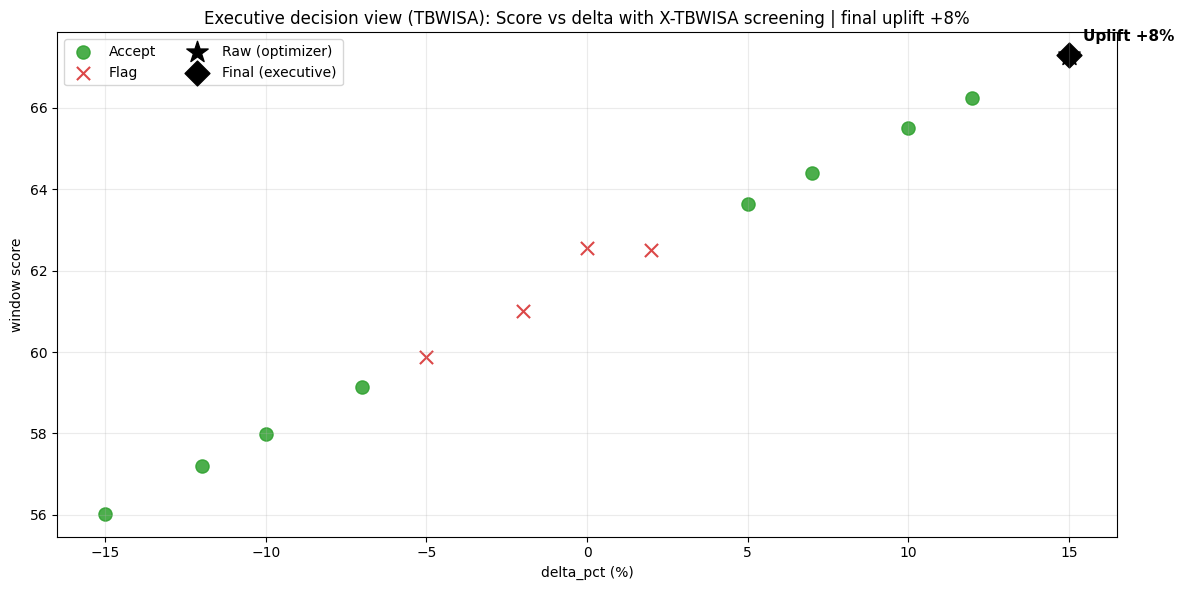

,delta_pct,score,uplift_pct,start,len,status,reason
12,15,67.295985,7.571322,14,7,Accept,ok
11,12,66.236292,5.877423,14,7,Accept,ok
10,10,65.519402,4.731489,14,7,Accept,ok
9,7,64.408006,2.954943,14,7,Accept,ok
8,5,63.650841,1.744631,14,7,Accept,ok
6,0,62.559411,0.000000,22,8,Flag,high_shap_drift
7,2,62.512691,-0.074681,14,7,Flag,"high_shap_drift,economic_plausibility_fail"
5,-2,61.004465,-2.485551,14,7,Flag,"high_shap_drift,economic_plausibility_fail"
4,-5,59.880703,-4.281862,14,7,Flag,high_shap_drift_price_dominated
3,-7,59.130882,-5.480437,14,7,Accept,ok


In [18]:
# Build executive decision scatter: delta vs window score, colored by X-TBWISA status
try:
    w_tb = windows[windows['model'].astype(str).str.lower()=='tbwisa'].copy()
    w_tb['delta_pct'] = w_tb['delta_pct'].astype(int)
    w_tb = w_tb.sort_values('delta_pct')
except Exception:
    w_tb = None

try:
    s_df = screening_df[['delta_pct','status','reason']].copy()
    s_df['delta_pct'] = s_df['delta_pct'].astype(int)
except Exception:
    s_df = None

if w_tb is not None and s_df is not None:
    exec_df = w_tb.merge(s_df, on='delta_pct', how='left')
    exec_df['status'] = exec_df['status'].fillna('Unscreened')

    # Determine final vs raw decision
    raw_delta = None
    final_delta = None
    score_gap = float(globals().get('ECON_FALLBACK_SCORE_GAP', 0.07))
    try:
        raw_delta = int(actionable_outcome.get('recommended_delta_pct_raw'))
        final_delta = int(actionable_outcome.get('recommended_delta_pct'))
    except Exception:
        try:
            raw_delta = int(best.get('recommended_delta_pct'))
            final_delta = raw_delta
        except Exception:
            pass

    # Colors / markers
    color_map = {
        'Accept': '#2ca02c',
        'Accept_Caution': '#ff7f0e',
        'Flag': '#d62728',
        'Unscreened': '#7f7f7f'
    }
    marker_map = {
        'Accept': 'o',
        'Accept_Caution': 's',
        'Flag': 'x',
        'Unscreened': 'o'
    }

    plt.figure(figsize=(12, 6))
    for st, g in exec_df.groupby('status'):
        c = color_map.get(st, '#7f7f7f')
        m = marker_map.get(st, 'o')
        plt.scatter(g['delta_pct'], g['score'], label=st, marker=m, s=90, c=c, alpha=0.85)

    # Highlight raw and final decision
    if raw_delta is not None:
        y_raw = float(exec_df[exec_df['delta_pct']==raw_delta]['score'].iloc[0])
        plt.scatter([raw_delta], [y_raw], marker='*', s=260, c='black', label='Raw (optimizer)')
    if final_delta is not None:
        y_fin = float(exec_df[exec_df['delta_pct']==final_delta]['score'].iloc[0])
        plt.scatter([final_delta], [y_fin], marker='D', s=160, c='black', label='Final (executive)')
        # Add uplift annotation (window uplift vs baseline delta=0)
        baseline_score = None
        try:
            baseline_score = float(exec_df.loc[exec_df['delta_pct']==0, 'score'].iloc[0])
        except Exception:
            baseline_score = None

        u_fin = None
        if baseline_score is not None and baseline_score != 0:
            exec_df['uplift_pct'] = 100.0 * (exec_df['score'] / baseline_score - 1.0)
            try:
                u_fin = float(exec_df.loc[exec_df['delta_pct']==final_delta, 'uplift_pct'].iloc[0])
                plt.annotate(f'Uplift {u_fin:+.0f}%', (final_delta, y_fin),
                             textcoords='offset points', xytext=(10, 10),
                             ha='left', fontsize=11, fontweight='bold', color='black')
            except Exception:
                pass

    # If fallback was active, draw threshold line
    try:
        if raw_delta is not None and final_delta is not None and raw_delta != final_delta:
            best_score = float(exec_df[exec_df['delta_pct']==raw_delta]['score'].iloc[0])
            plt.axhline(best_score*(1.0-score_gap), linestyle='--', linewidth=1.4, c='black', alpha=0.6,
                        label=f'Fallback threshold (1-{score_gap:.0%})')
    except Exception:
        pass

    title = 'Executive decision view (TBWISA): Score vs delta with X-TBWISA screening'
    try:
        if u_fin is not None:
            title += f' | final uplift {u_fin:+.0f}%'
    except Exception:
        pass
    plt.title(title)
    plt.xlabel('delta_pct (%)')
    plt.ylabel('window score')
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'executive_decision_view_case_sku_{CASE_SKU}.png', dpi=160, bbox_inches='tight')
    plt.show()

    cols = ['delta_pct','score','start','len','status','reason']
    if 'uplift_pct' in exec_df.columns:
        cols = ['delta_pct','score','uplift_pct','start','len','status','reason']
    display(exec_df[cols].sort_values('score', ascending=False))
else:
    print('Missing windows or screening_df; run scenario evaluation and X-TBWISA screening first.')

### Additional exported tables for extended thesis reporting

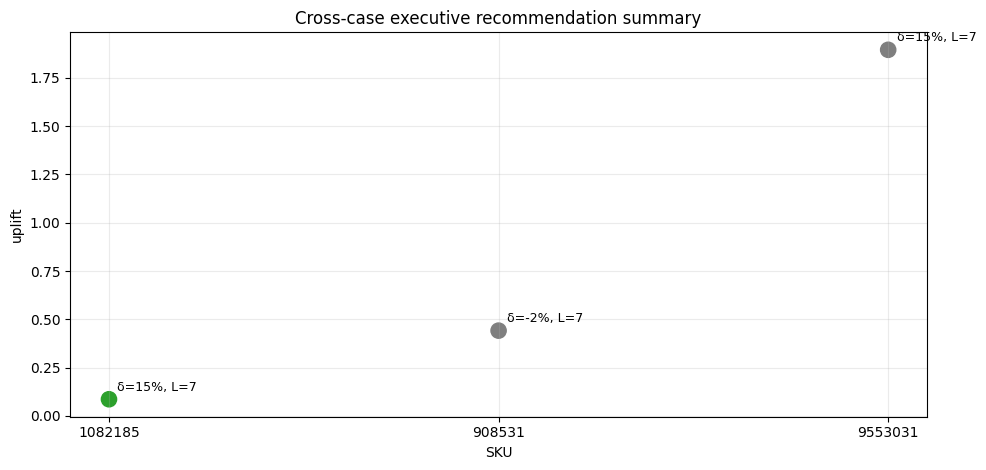

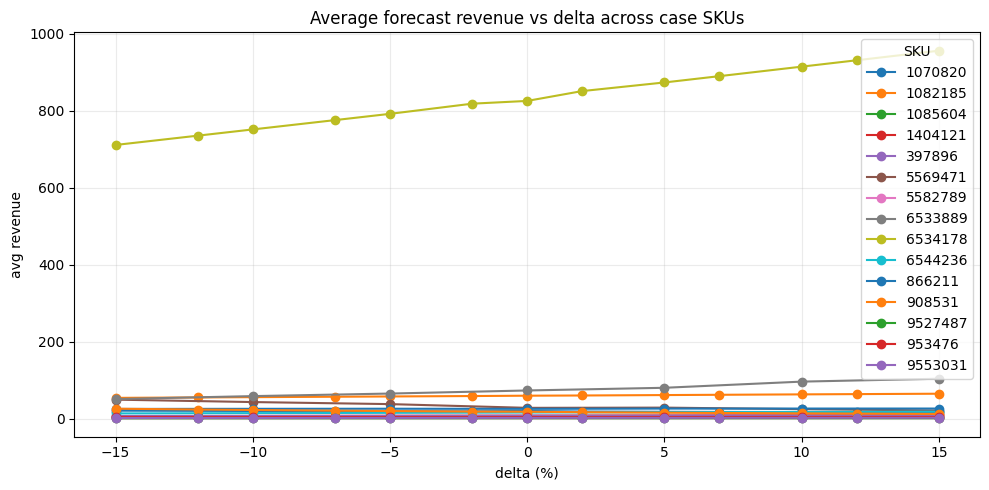

Additional DIF-PI tables written:
- integrated_recommendation_summary.csv
- average_forecast_revenue_vs_delta_across_case_skus.csv
- appendix_e_table_e1_top_ranked_screened_alternatives.csv


In [19]:
dif_pi_extended_reporting_tables = []

# Cross-case comparative summary from already-run case SKUs.
# This intentionally loads the aggregated CSV because each case SKU is run separately,
# and the file is built from the per-case recommendation exports.
summary_csv = OUT_DIR / 'integrated_recommendation_summary.csv'
if summary_csv.exists():
    integrated_recommendation_summary = pd.read_csv(summary_csv)
else:
    integrated_recommendation_summary = pd.DataFrame()
    print('Run at least one case SKU first; integrated_recommendation_summary.csv is not available yet.')

if len(integrated_recommendation_summary):
    integrated_recommendation_summary.to_csv(
        OUT_DIR / 'integrated_recommendation_summary.csv',
        index=False
    )
    dif_pi_extended_reporting_tables.append((
        'Integrated recommendation summary',
        'integrated_recommendation_summary.csv',
        integrated_recommendation_summary
    ))

    plot_df = integrated_recommendation_summary.copy()
    if 'uplift' in plot_df.columns:
        plot_df['uplift'] = pd.to_numeric(plot_df['uplift'], errors='coerce')

        color_map = {
            'Accept': '#2ca02c',
            'Accept_Caution': '#ff7f0e',
            'Flag': '#d62728',
            'Unscreened': '#7f7f7f'
        }
        colors = [
            color_map.get(str(s), '#7f7f7f')
            for s in plot_df.get('screening_status', pd.Series(['Unscreened'] * len(plot_df))).astype(str)
        ]

        plt.figure(figsize=(10, 4.8))
        plt.scatter(plot_df['sku'].astype(str), plot_df['uplift'], s=120, c=colors)

        required_annotation_cols = {'recommended_delta', 'window_length_days'}
        if required_annotation_cols.issubset(plot_df.columns):
            for _, row in plot_df.iterrows():
                y_val = float(row['uplift']) if pd.notna(row['uplift']) else 0.0
                plt.annotate(
                    f"δ={int(row['recommended_delta'])}%, L={int(row['window_length_days'])}",
                    (str(row['sku']), y_val),
                    textcoords='offset points',
                    xytext=(6, 6),
                    fontsize=9
                )

        plt.title('Cross-case executive recommendation summary')
        plt.xlabel('SKU')
        plt.ylabel('uplift')
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(
            OUT_DIR / 'cross_case_executive_recommendation_summary.png',
            dpi=160,
            bbox_inches='tight'
        )
        plt.show()

# Average forecast revenue vs delta across case SKUs
metric_rows = []
for p in sorted(OUT_DIR.glob('metrics_case_sku_*.csv')):
    sku = p.stem.split('metrics_case_sku_')[-1]
    df = pd.read_csv(p)

    required_cols = {'model', 'delta_pct', 'avg_rev_forecast'}
    if not required_cols.issubset(df.columns):
        continue

    df = df[df['model'].astype(str).str.lower().eq('tbwisa')].copy()
    if len(df):
        df['sku'] = str(sku)
        metric_rows.append(df[['sku', 'delta_pct', 'avg_rev_forecast']])

if metric_rows:
    average_forecast_revenue_vs_delta_across_case_skus = (
        pd.concat(metric_rows, ignore_index=True)
        .sort_values(['sku', 'delta_pct'])
        .reset_index(drop=True)
    )
    average_forecast_revenue_vs_delta_across_case_skus.to_csv(
        OUT_DIR / 'average_forecast_revenue_vs_delta_across_case_skus.csv',
        index=False
    )
    dif_pi_extended_reporting_tables.append((
        'Average forecast revenue vs delta across case SKUs',
        'average_forecast_revenue_vs_delta_across_case_skus.csv',
        average_forecast_revenue_vs_delta_across_case_skus
    ))

    plt.figure(figsize=(10, 5))
    for sku, g in average_forecast_revenue_vs_delta_across_case_skus.groupby('sku'):
        g = g.sort_values('delta_pct')
        plt.plot(g['delta_pct'], g['avg_rev_forecast'], marker='o', label=str(sku))

    plt.title('Average forecast revenue vs delta across case SKUs')
    plt.xlabel('delta (%)')
    plt.ylabel('avg revenue')
    plt.grid(True, alpha=0.25)
    plt.legend(title='SKU')
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / 'average_forecast_revenue_vs_delta_across_case_skus.png',
        dpi=160,
        bbox_inches='tight'
    )
    plt.show()
else:
    average_forecast_revenue_vs_delta_across_case_skus = pd.DataFrame()
    print('No metrics_case_sku_*.csv files found for the cross-case revenue summary.')

# Top ranked screened decision alternatives for the three case SKUs
case_regime_names = {
    'regular': SKU_REG,
    'intermittent': SKU_INT,
    'price_sensitive': SKU_PS
}

appendix_e_rows = []

for regime, sku in case_regime_names.items():
    csv_path = OUT_DIR / f'decision_table_screened_case_sku_{sku}.csv'

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        # Keep top 3 rows, assuming the decision table is already ranked by the notebook logic.
        df_top3 = df.head(3).copy()
        df_top3['case_sku'] = str(sku)
        df_top3['regime'] = str(regime)

        cols_to_keep = [
            'case_sku',
            'regime',
            'model',
            'delta_pct',
            'window_start_offset_days',
            'window_length_days',
            'uplift_ratio',
            'window_score',
            'x_tbwisa_status'
        ]
        cols_present = [c for c in cols_to_keep if c in df_top3.columns]
        df_top3 = df_top3[cols_present]

        if 'x_tbwisa_status' in df_top3.columns:
            df_top3 = df_top3.rename(columns={'x_tbwisa_status': 'status'})

        appendix_e_rows.append(df_top3)
    else:
        print(f'Warning: {csv_path} not found for {regime} case.')

if appendix_e_rows:
    appendix_e_table_e1_top_ranked_screened_alternatives = (
        pd.concat(appendix_e_rows, ignore_index=True)
        .reset_index(drop=True)
    )

    col_order = [
        'case_sku',
        'regime',
        'model',
        'delta_pct',
        'window_start_offset_days',
        'window_length_days',
        'uplift_ratio',
        'window_score',
        'status'
    ]
    col_order = [c for c in col_order if c in appendix_e_table_e1_top_ranked_screened_alternatives.columns]
    appendix_e_table_e1_top_ranked_screened_alternatives = appendix_e_table_e1_top_ranked_screened_alternatives[col_order]

    appendix_e_table_e1_top_ranked_screened_alternatives.to_csv(
        OUT_DIR / 'appendix_e_table_e1_top_ranked_screened_alternatives.csv',
        index=False
    )
    dif_pi_extended_reporting_tables.append((
        'Top ranked screened decision alternatives for the three case SKUs',
        'appendix_e_table_e1_top_ranked_screened_alternatives.csv',
        appendix_e_table_e1_top_ranked_screened_alternatives
    ))
else:
    appendix_e_table_e1_top_ranked_screened_alternatives = pd.DataFrame()
    print('No decision_table_screened files found for the three case SKUs.')

print('Additional DIF-PI tables written:')
for _, file_name, table in dif_pi_extended_reporting_tables:
    print('-', file_name)

In [20]:
# Display additional DIF-PI thesis reporting tables

for table_name, _, table in dif_pi_extended_reporting_tables:
    print(f'\n{table_name}')
    display(table)


Integrated recommendation summary


,sku,regime_note,recommended_delta,window_start_offset_days,window_length_days,uplift,screening_status,comment
0,1082185,regular,15,14,7,0.086444,Accept,NaN
1,908531,price_sensitive,-2,23,7,0.441601,NaN,NaN
2,9553031,intermittent,15,10,7,1.895178,NaN,NaN



Average forecast revenue vs delta across case SKUs


,sku,delta_pct,avg_rev_forecast
0,1070820,-15,20.504580
1,1070820,-12,20.057317
2,1070820,-10,19.763246
3,1070820,-7,19.326586
4,1070820,-5,19.066641
...,...,...,...
148,9553031,5,1.836838
149,9553031,7,1.867912
150,9553031,10,1.915219
151,9553031,12,1.946733



Top ranked screened decision alternatives for the three case SKUs


,case_sku,regime,model,window_start_offset_days,window_length_days,uplift_ratio,window_score,status
0,1082185,regular,tbwisa,14,7,0.086444,67.295985,Accept
1,1082185,regular,loglinear,22,8,0.000000,62.559411,NaN
2,1082185,regular,xgboost,22,8,0.000000,62.559411,NaN
3,9553031,intermittent,xgboost,10,7,1.895178,5.233987,NaN
4,9553031,intermittent,tbwisa,19,8,0.122263,2.297852,Accept_Caution
5,9553031,intermittent,loglinear,19,8,0.000000,2.077032,NaN
6,908531,price_sensitive,xgboost,23,7,0.441601,28.668786,NaN
7,908531,price_sensitive,tbwisa,21,9,0.433556,28.064475,Accept
8,908531,price_sensitive,loglinear,22,8,0.000000,19.732197,NaN
